# Phrase Segmentation - EA-Digifolk Dataset Analysis


> This notebook extends the original EA-Digifolk dataset explorer with additional analyses developed for the dissertation.



Links:

* [EA-Digifolk dataset](https://github.com/EA-Digifolk/EA-Digifolk-Dataset.git)
* [Extract Features from MEI Parser](https://github.com/EA-Digifolk/MEIParser_features)

## Setup

This section covers downloading the the [EA-Digifolk dataset](https://github.com/EA-Digifolk/EA-Digifolk-Dataset.git) and the [Parser](https://github.com/EA-Digifolk/MEIParser_features) to extract features from MEI files, and installing the required libraries for the parser to function, and the [Musescore](https://musescore.org) software for displaying the musical scores.

In [ ]:
%%capture
#@title Download the EA-Digifolk Dataset from Github
%cd /content

import os
if os.path.exists('EA-Digifolk-Dataset'):
  !git -C EA-Digifolk-Dataset pull
else:
  !git clone https://github.com/EA-Digifolk/EA-Digifolk-Dataset.git

In [ ]:
%%capture
%cd /content
#@title Download the MEI Parser

import os
if os.path.exists('MEIParser_features'):
  !git -C MEIParser_features pull
else:
  !git clone https://github.com/EA-Digifolk/MEIParser_features


!pip install -r MEIParser_features/requirements.txt -q

import sys
if not '/content/MEIParser_features' in sys.path:
  sys.path.append('/content/MEIParser_features')

In [ ]:
%%capture
#@title Install Musescore
!apt-get update -q && apt-get install musescore lilypond -q
%env QT_QPA_PLATFORM=offscreen

In [ ]:
#@title Install Music21 and setup Musescore in the Music21 Environment
!pip install music21 -q

import music21
env = music21.environment.Environment()
env['lilypondPath'] = '/usr/local/bin/lilypond'
env['pdfPath'] = '/usr/bin/musescore'
env['graphicsPath'] = '/usr/bin/musescore'
env['musicxmlPath'] = '/usr/bin/musescore'
env['musescoreDirectPNGPath'] = '/usr/bin/musescore'
env['autoDownload'] = 'allow'
env['warnings'] = 0

In [ ]:
#@title Install fluidsynth for audio playback in Colab
!apt-get update -qq && apt-get install -qq libfluidsynth1 fluid-soundfont-gm
!pip install fluidsynth

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu noble InRelease' does not seem to provide it (sources.list entry misspelt?)
E: Package 'libfluidsynth1' has no installation candidate


## Extract features from MEI files

This section covers the processing of the dataset: extracting the features from the MEI files and saving them as a pandas dataframe for easy exploration.

The whole dataset is processed, using the current country folders (`Spain/`, `Portugal/`, `Mexico/`, `Italy/`, `Colombia/`, `Ireland/`, `Miscellanous/`). The folders `Spanish/`, `Portuguese/` and `Mexican/` contain versions of the same Spanish, Portuguese and Mexican songs, so they are excluded to avoid duplicates and identified as "legacy".

The `EADIGIFOLK.gzip` file available in the repository was generated from the legacy folders only, so the dataframe is regenerated here and saved to `EADIGIFOLK_PATH`. If that file already exists, processing is skipped (set `REPROCESS = True` to force it).

In [ ]:
#@title Dataset files and parser compatibility patches

import os, re, sys, glob
import pandas as pd

DATA_DIR = '/content/EA-Digifolk-Dataset'

# Current folders of the dataset
# The folders (Spanish/, Portuguese/, Mexican/) are not used to avoid duplicates
DATASET_FOLDERS = ['Spain', 'Portugal', 'Mexico', 'Italy', 'Colombia', 'Ireland', 'Miscellanous']
LEGACY_FOLDERS = ['Spanish', 'Portuguese', 'Mexican']
FOLDER_COUNTRY = {'Spain': 'ES', 'Portugal': 'PT', 'Mexico': 'MX', 'Italy': 'IT',
                  'Colombia': 'CO', 'Ireland': 'IE', 'Miscellanous': 'MI'}

# Files excluded in the original notebook
EXCLUDED_FILES = ['ES-1948-AS-FP-006', 'ES-1948-CB-CO-376', 'ES-1948-CB-CO-418', 'ES-1991-CL-KS-147']

# The path where the regenerated dataframe is saved.
# To keep it between Colab sessions, use the commented line below
#EADIGIFOLK_PATH = '/content/drive/MyDrive/EADIGIFOLK.gzip'
EADIGIFOLK_PATH = '/content/EADIGIFOLK.gzip'

def song_id_from_path(path):
    return os.path.basename(path).replace('.mei', '').replace('_updated', '')

def folder_of(path):
    return os.path.relpath(path, DATA_DIR).split(os.sep)[0]

def country_of(path):
    sid = song_id_from_path(path)
    if re.match(r'^[A-Z]{2}-\d{4}', sid):
        return sid.split('-')[0]
    return FOLDER_COUNTRY.get(folder_of(path), '?')

def get_dataset_files():
    files = sorted(f for d in DATASET_FOLDERS for f in glob.glob(os.path.join(DATA_DIR, d, '**', '*.mei'), recursive=True))
    files = [f for f in files if song_id_from_path(f) not in EXCLUDED_FILES]
    # if the same song ID appears twice (e.g. 'X.mei' and 'X_updated.mei'), keep the '_updated' version
    by_id = {}
    for f in files:
        sid = song_id_from_path(f)
        if sid not in by_id or f.endswith('_updated.mei'):
            by_id[sid] = f
    return sorted(by_id.values())

DATASET_FILES = get_dataset_files()
print(f'{len(DATASET_FILES)} MEI files in {DATASET_FOLDERS}')
display(pd.Series([folder_of(f) for f in DATASET_FILES]).value_counts().rename('files').to_frame())

# Parser compatibility patches (the repository is not modified)
if '/content/MEIParser_features' not in sys.path:
    sys.path.append('/content/MEIParser_features')
import parser_mei_features
from parser_mei_features import MeiParser, NAME_SPACE
import parser_mei_features.mtc_extractor as _mtc


# 1) Compatibility fix for the <key>/<mode> representation.
# New MEI files use:
#     <key>C</key>
#     <mode>major</mode>
# while the parser expects:
#     <key mode="major">C</key>
if not getattr(MeiParser, '_compat_patched', False):
    # Keep the original parser method so we can call it when
    # the compatibility fix is not required.
    original_get_element = MeiParser.get_element
    def get_element_with_mode_compatibility(self, root, xpath, retrieve='text'):
        element = root.find(xpath, NAME_SPACE)
        if (element is not None and retrieve != 'text' and retrieve not in element.attrib):
            if retrieve == 'mode':
                mode_element = root.find('.//mei:work//mei:mode', NAME_SPACE)
                return (mode_element.text.strip()
                    if mode_element is not None and mode_element.text
                    else None
                )
            return None
        return original_get_element(self, root, xpath, retrieve)

    MeiParser.get_element = get_element_with_mode_compatibility

    # 2) Ensure that every song has an ID in its musical metadata.
    # If phrase extraction fails, the parser uses this ID when
    # reporting the problem. Without it, the entire song may be lost.

    original_mtc_extractor_init = _mtc.MTCExtractor.__init__

    def mtc_extractor_init_with_song_id(self, path, mei_tree, musical_metadata=None):
        if musical_metadata is not None:
            musical_metadata.setdefault('id', song_id_from_path(path))
        original_mtc_extractor_init(self, path, mei_tree, musical_metadata)

    _mtc.MTCExtractor.__init__ = mtc_extractor_init_with_song_id
    MeiParser._compat_patched = True

try:
    import verovio
    verovio.enableLog(verovio.LOG_OFF)
except Exception:
    pass


2414 MEI files in ['Spain', 'Portugal', 'Mexico', 'Italy', 'Colombia', 'Ireland', 'Miscellanous']


,files
Spain,1382
Mexico,565
Ireland,195
Colombia,92
Miscellanous,61
Italy,60
Portugal,59


In [ ]:
# @title Process Dataset

import io
import queue
import contextlib
import multiprocessing as mp
import pandas as pd
from tqdm.auto import tqdm
from parser_mei_features import MeiParser

REPROCESS = False   # True: regenerate the dataframe even if EADIGIFOLK_PATH already exists
TIMEOUT = 120       # seconds per file; slower files are skipped and reported as errors

def worker(inbox, outbox):
    """Separate process: parses each file it receives (parser output hidden) and sends back the result."""
    for song in iter(inbox.get, None):
        try:
            with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):
                outbox.put(MeiParser().parse_mei(song, verbose=False))
        except Exception as e:
            outbox.put(e.__class__.__name__)

def start_worker():
    ctx = mp.get_context('fork')   # fork keeps the parser patches in the worker
    inbox, outbox = ctx.Queue(), ctx.Queue()
    proc = ctx.Process(target=worker, args=(inbox, outbox), daemon=True)
    proc.start()
    return proc, inbox, outbox

if os.path.exists(EADIGIFOLK_PATH) and not REPROCESS:
    print(f'{EADIGIFOLK_PATH} already exists: skipping processing (set REPROCESS = True to force it).')
else:
    rows, errors = [], []
    proc, inbox, outbox = start_worker()

    for song in tqdm(DATASET_FILES, desc='Processing MEI files'):
        inbox.put(song)
        try:
            result = outbox.get(timeout=TIMEOUT)
        except queue.Empty:                          # stuck file: kill the worker and start a new one
            errors.append((song, 'Timeout'))
            proc.kill()
            proc, inbox, outbox = start_worker()
            continue
        if not isinstance(result, dict):             # parser error (or no features)
            errors.append((song, result or 'NoFeatures'))
            continue
        voices = list(result.values())               # v1, v2, ... (extra voices come from chords)
        row = voices[0]                              # one row per song: the melody
        row['mei_id'] = row.get('id')                # ID written inside the MEI (often missing)
        row['id'] = song_id_from_path(song)          # unique ID from the file name (index)
        row['file'] = song
        row['n_voices'] = len(voices)
        rows.append(row)

    inbox.put(None)
    proc.kill()

    EADIGIFOLK = pd.DataFrame(rows).set_index('id')
    EADIGIFOLKNT = EADIGIFOLK   # marks that the data was processed in this session (used by Clean/Save)

    PARSE_ERRORS = pd.DataFrame(errors, columns=['file', 'error'])
    PARSE_ERRORS['folder'] = PARSE_ERRORS['file'].map(folder_of)
    print(f'{len(rows)} files processed | {len(errors)} files with errors')
    if len(errors):
        display(PARSE_ERRORS.groupby(['folder', 'error']).size().rename('files').to_frame())


Processing MEI files:   0%|          | 0/2414 [00:00<?, ?it/s]

1836 files processed | 578 files with errors


files
folder       error                 
Ireland      IndexError          56
             KeyError            56
Mexico       IndexError           1
Miscellanous IndexError           8
             TypeError            1
Spain        IndexError          32
             KeyError            42
             MeiElementError    381
             Timeout              1

In [ ]:
EADIGIFOLK['country'] = EADIGIFOLK.index.to_series().apply(lambda x: x.split('-')[0])
# clean meters
EADIGIFOLK.loc[EADIGIFOLK['meter'].str.contains('bin|Bin', case=False, regex=True, na=False), 'meter'] = 'Binary'
EADIGIFOLK.loc[EADIGIFOLK['meter'].str.contains('ter|Ter|tri|Tri', case=False, regex=True, na=False), 'meter'] = 'Ternary'
EADIGIFOLK.loc[EADIGIFOLK['meter'].str.contains('com|Com', case=False, regex=True, na=False), 'meter'] = 'Compound'
EADIGIFOLK.loc[EADIGIFOLK['meter'].str.contains('fr|Fr', case=False, regex=True, na=False), 'meter'] = 'Free'
EADIGIFOLK.loc[EADIGIFOLK['meter'].str.contains('poly|Poly', case=False, regex=True, na=False), 'meter'] = 'Polyrhythmic'
EADIGIFOLK.loc[EADIGIFOLK['meter'].str.contains('irr|Irr', case=False, regex=True, na=False), 'meter'] = 'Polyrhythmic'
# clean genres
EADIGIFOLK.loc[EADIGIFOLK['genre'].str.contains('lul|Lul', case=False, regex=True, na=False), 'genre'] = 'Lullaby'
EADIGIFOLK.loc[EADIGIFOLK['genre'].str.contains('dan|Dan', case=False, regex=True, na=False), 'genre'] = 'Dance'
EADIGIFOLK.loc[EADIGIFOLK['genre'].str.contains('corro|Corro|canción|Canción|Child|child', case=False, regex=True, na=False), 'genre'] = 'Childhood Music'

In [ ]:
#@title Save Dataset
# Save Dataframe to compressed file to save
EADIGIFOLK.to_pickle('EADIGIFOLK.gzip', compression={'method': 'gzip', 'compresslevel': 1, 'mtime': 1})
print('Saved to', EADIGIFOLK_PATH)


Saved to /content/EADIGIFOLK.gzip


## Exploring the EA-Digifolk Dataset

This section covers possible ways of exploring the dataset.

In [ ]:
#@title Import saved pandas dataframe

import pandas as pd
import statistics
from collections import Counter

print(EADIGIFOLK_PATH)

if os.path.exists(EADIGIFOLK_PATH):
    EADIGIFOLK = pd.read_pickle(EADIGIFOLK_PATH, compression={'method': 'gzip', 'compresslevel': 1, 'mtime': 1})
else:
    print('WARNING: the full dataframe was not found; loading the dataframe from the repository '
          '(Spanish/Portuguese/Mexican folders only). Run the "Process Dataset" cell first.')
    EADIGIFOLK = pd.read_pickle("/content/EA-Digifolk-Dataset/EADIGIFOLK.gzip", compression={'method': 'gzip', 'compresslevel': 1, 'mtime': 1})

print(f"{len(EADIGIFOLK)} songs | {int((EADIGIFOLK['n_voices'] > 1).sum())} with chords split into extra voices (only the melody is kept)")
display(EADIGIFOLK['country'].value_counts())
display(EADIGIFOLK['genre'].value_counts())



/content/EADIGIFOLK.gzip
1836 songs | 234 with chords split into extra voices (only the melody is kept)


,count
country,
ES,783
MX,564
CO,92
IE,79
IT,60
...,...
"96. Retírate, flor de la aldea",1
97. Si la nieve resbala,1
98a. Si pasas el río I,1


,count
genre,
Childhood Music,1025
Lullaby,173
Narrative Genre,168
Community Festive Secular Music,98
Religious and Ritual Music,55
Work Music,15
Dance,9
Filastrocca,1


In [ ]:
#@title Helpers used by the exploration cells below
COUNTRY_OPTIONS = {'all': None, 'spanish': 'ES', 'portuguese': 'PT', 'mexican': 'MX', 'italian': 'IT',
                   'colombian': 'CO', 'irish': 'IE', 'miscellaneous': 'MI'}

def filter_country(df, dataset):
    code = COUNTRY_OPTIONS.get(dataset)
    return df if code is None else df[df['country'] == code]

def n_phrases(features):
    ix = features.get('phrase_ix', []) if hasattr(features, 'get') else []
    return len(set(ix))

def mean_notes_per_phrase(features):
    ix = features.get('phrase_ix', []) if hasattr(features, 'get') else []
    return int(statistics.mean(Counter(ix).values())) if len(ix) else 0

In [ ]:
#@title List all songs in the dataset

import pandas as pd
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

EADIGIFOLK

,title,subtitle,compiler,informer,geographic,encoder,editor,source_id,source_title,source_subtitle,source_compiler,source_informer,bibliography,introduction,edition,publisher,publication_place,date,pages,ambitus_lowest,ambitus_highest,pitch_pattern,interval_pattern,rhythm_pattern,phrases,key,mode,meter,tempo,genre,ngram,bigram,textual_topics,has_lyrics?,has_freemeter?,features,mei_id,file,n_voices,country
id,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
CO-1935-00-LL-03561,Nana,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,NaN,NaN,None,None,None,None,None,None,None,,None,None,Childhood Music,None,None,[],Vocal,False,"{'id': ['n3gipoq', 'nd43zc', 'n1cutctu', 'nb93...",CO-1935-00-LL-03561,/content/EA-Digifolk-Dataset/Colombia/CO-1935-...,1,CO
CO-1935-00-LL-03562,La lluvia,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,NaN,NaN,None,None,None,None,None,None,None,,None,None,Childhood Music,None,None,[],Vocal,False,"{'id': ['n1kh9vfh', 'nhhr1ry', 'ntyvqho', 'noc...",CO-1935-00-LL-03562,/content/EA-Digifolk-Dataset/Colombia/CO-1935-...,1,CO
CO-1935-00-LL-03563,Ave Maris Stella,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,NaN,NaN,None,None,None,None,None,None,None,,None,None,Childhood Music,None,None,[],Vocal,False,"{'id': ['nmpyawf', 'nbs7p4a', 'nnz3acr', 'n118...",CO-1935-00-LL-03563,/content/EA-Digifolk-Dataset/Colombia/CO-1935-...,1,CO
CO-1935-00-LL-03564,El turpial,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,NaN,NaN,None,None,None,None,None,None,None,,None,None,Childhood Music,None,None,[],Vocal,False,"{'id': ['nhluwq9', 'n1ulva02', 'n7pdf2t', 'n4g...",CO-1935-00-LL-03564,/content/EA-Digifolk-Dataset/Colombia/CO-1935-...,1,CO
CO-1935-00-LL-03565,¿Qué haces tú?,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,NaN,NaN,None,None,None,None,None,None,None,,None,None,Childhood Music,None,None,[],Vocal,False,"{'id': ['nnkhuo5', 'ncf6308', 'n9do28k', 'ny17...",CO-1935-00-LL-03565,/content/EA-Digifolk-Dataset/Colombia/CO-1935-...,1,CO
CO-1935-00-LL-03566,Pregones,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,NaN,NaN,None,None,None,None,None,None,None,,None,None,Childhood Music,None,None,[],Vocal,False,"{'id': ['ndmfpay', 'n5p7uve', 'n12mctda', 'nsd...",CO-1935-00-LL-03566,/content/EA-Digifolk-Dataset/Colombia/CO-1935-...,1,CO
CO-1935-00-LL-03567,La gallinita,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,NaN,NaN,None,None,None,None,None,None,None,,None,None,Childhood Music,None,None,[],Vocal,False,"{'id': ['nfqxo3l', 'n1spx8kf', 'nlfm53f', 'n1n...",CO-1935-00-LL-03567,/content/EA-Digifolk-Dataset/Colombia/CO-1935-...,1,CO
CO-1935-00-LL-03568,El grillo,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,NaN,NaN,None,None,None,None,None,None,None,,None,None,Childhood Music,None,None,[],Vocal,False,"{'id': ['na6tvny', 'n19cprqm', 'n1iema4k', 'ng...",CO-1935-00-LL-03568,/content/EA-Digifolk-Dataset/Colombia/CO-1935-...,1,CO
CO-1935-00-LL-03569,A mí me gusta lo blanco,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,NaN,NaN,None,None,None,None,None,None,None,,None,None,Childhood Music,None,None,[],Vocal,False,"{'id': ['ney5avo', 'n1ficriu', 'n70s78s', 'nry...",CO-1935-00-LL-03569,/content/EA-Digifolk-Dataset/Colombia/CO-1935-...,1,CO


Showing: /content/EA-Digifolk-Dataset/Portugal/PT-1998-PT-DM/PT-1998-PT-DM-011.mei

Score: 



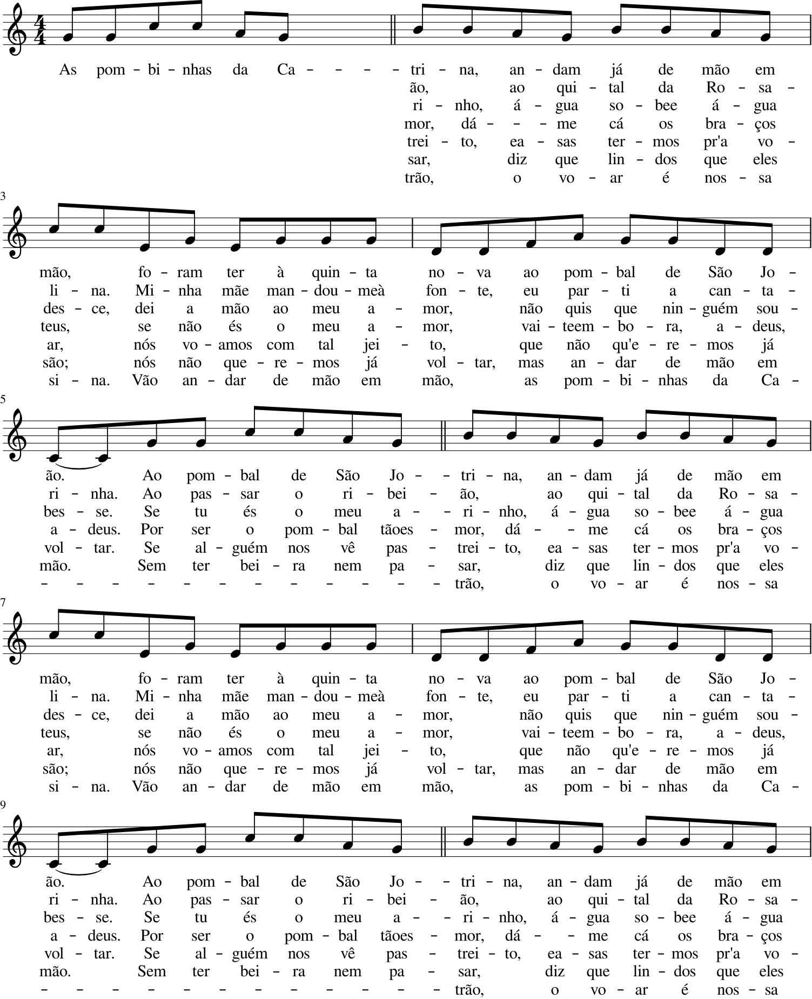


Metadata Features: 



,PT-1998-PT-DM-011
title,As Pombinhas Da Catrina
subtitle,As Pombinhas Da Catrina
compiler,Domingos Morais
encoder,Sara González
source_id,Morais1998PT
source_title,Cantar Em Português
source_subtitle,"Selecção, Versões Karaoke E Notas"
source_compiler,Domingos Morais
publisher,Universidade Do Minho
publication_place,Online



Note Features: 



,id,scaledegree,scaledegreespecifier,tonic,mode,pitch,midipitch,pitch40,diatonicpitch,chromaticinterval,diatonicinterval,pitchproximity,pitchreversal,contour3,contour5,offsets,duration,duration_frac,duration_fullname,nextisrest,restduration_frac,onsettick,durationcontour,songpos,ima,ima_contour,timesignature,beat,beat_str,beat_fraction_str,beatstrength,metriccontour,posinbar,phrasepos,phrase_ix,phrase_end,beatinsong,beatinphrase,beatfractioninphrase,beatinphrase_end,ioi_frac,ioi,ior_frac,ior,gpr2a_Frankland,gpr2b_Frankland,gpr3a_Frankland,gpr3d_Frankland,gpr_Frankland_sum,lbdm_rpitch,lbdm_spitch,lbdm_rioi,lbdm_sioi,lbdm_rrest,lbdm_srest,lbdm_boundarystrength,lyrics
0,nv1748b,5,P,C,Major,G4,67,146,33,NaN,NaN,NaN,NaN,None,None,1.0,0.5,1/2,Eighth,False,None,2,None,0.008889,1.0,None,4/4,1.0,1,0,0.250,None,0.000,0.000000,0,False,0,0,1/2,-7,1/2,0.5,None,NaN,None,None,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"[(1, As, single)]"
1,n651b2d,5,P,C,Major,G4,67,146,33,0.0,0.0,NaN,NaN,=,=,1.5,0.5,1/2,Eighth,False,None,3,=,0.013333,1.0,=,4/4,1.5,1,1/2,0.125,-,0.125,0.066667,0,False,1/2,1/2,1/2,-13/2,1/2,0.5,1,1.0,None,None,1.000000,1.0,2.000000,0.714286,0.655977,0.0,0.0,0.0,0.0,0.163994,"[(1, pom, begin)]"
2,n1ikpseu,1,P,C,Major,C5,72,163,36,5.0,3.0,5.0,0.0,+,++,2.0,0.5,1/2,Eighth,False,None,4,=,0.017778,1.0,=,4/4,2.0,2,0,0.500,+,0.250,0.133333,0,False,1,1,1/2,-6,1/2,0.5,1,1.0,None,None,NaN,1.0,1.000000,0.714286,0.000000,0.0,0.0,0.0,0.0,0.000000,"[(1, bi, middle)]"
3,nu6s8yw,1,P,C,Major,C5,72,163,36,0.0,0.0,0.0,0.0,=,=,2.5,0.5,1/2,Eighth,False,None,5,=,0.022222,1.0,=,4/4,2.5,2,1/2,0.125,-,0.375,0.200000,0,False,3/2,3/2,1/2,-11/2,1/2,0.5,1,1.0,None,None,0.666667,1.0,1.666667,0.600000,0.204665,0.0,0.0,0.0,0.0,0.051166,"[(1, nhas, end)]"
4,n1esu87,6,M,C,Major,A4,69,152,34,-3.0,-2.0,3.0,0.0,-,--,3.0,0.5,1/2,Eighth,False,None,6,=,0.026667,1.0,=,4/4,3.0,3,0,0.250,+,0.500,0.266667,0,False,2,2,1/2,-5,1/2,0.5,1,1.0,None,None,NaN,1.0,1.000000,0.142857,0.072157,0.0,0.0,0.0,0.0,0.018039,"[(1, da, single)]"
5,nu1p5vb,5,P,C,Major,G4,67,146,33,-2.0,-1.0,2.0,0.0,-,-,3.5,0.5,1/2,Eighth,False,None,7,=,0.031111,1.0,=,4/4,3.5,3,1/2,0.125,-,0.625,0.333333,0,False,5/2,5/2,1/2,-9/2,1/2,0.5,1,1.0,None,None,0.750000,1.0,1.750000,0.250000,0.336735,0.0,0.0,0.0,0.0,0.084184,"[(1, Ca, begin)]"
6,n13j0h53,7,M,C,Major,B4,71,158,35,4.0,2.0,4.0,1.5,+,++,4.0,0.5,1/2,Eighth,False,None,8,=,0.035556,1.0,=,4/4,1.0,1,0,1.000,+,0.000,0.400000,0,False,3,3,1/2,-4,1/2,0.5,1,1.0,None,None,NaN,1.0,1.000000,0.666667,0.000000,0.0,0.0,0.0,0.0,0.000000,"[(1, tri, middle), (2, ão,, end), (3, ri, midd..."
7,n10ltebf,7,M,C,Major,B4,71,158,35,0.0,0.0,0.0,0.0,=,=,4.5,0.5,1/2,Eighth,False,None,9,=,0.040000,1.0,=,4/4,1.5,1,1/2,0.125,-,0.125,0.466667,0,False,7/2,7/2,1/2,-7/2,1/2,0.5,1,1.0,None,None,NaN,1.0,1.000000,0.500000,0.091837,0.0,0.0,0.0,0.0,0.022959,"[(1, na,, end), (3, nho,, end), (4, dá, begin)..."
8,nz758g0,6,M,C,Major,A4,69,152,34,-2.0,-1.0,2.0,0.0,-,-,5.0,0.5,1/2,Eighth,False,None,10,=,0.044444,1.0,=,4/4,2.0,2,0,0.250,+,0.250,0.533333,0,False,4,4,1/2,-3,1/2,0.5,1,1.0,None,None,NaN,1.0,1.000000,0.000000,0.045918,0.0,0.0,0.0,0.0,0.011480,"[(1, an, begin), (3, á, begin), (5, ea, begin)..."
9,n14cfsqn,5,P,C,Major,G4,67,146,33,-2.0,-1.0,2.0,0.0,-,-,5.5,0.5,1/2,Eighth,False,None,11,=,0.048889,1.0,=,4/4,2.5,2,1/2,0.125,-,0.375,0.600000,0,False,9/2,9/2,1/2,-5/2,1/2,0.5,1,1.0,None,None,0.750000,1.0,1.750000,0.250000,0.336735,0.0,0.0,0.0,0.0,0.084184,"[(1, dam, end), (3, gua, end), (4, me, end), (..."


In [ ]:
#@title View Song

#@markdown

from IPython.display import Audio

ID = "PT-1998-PT-DM-011" # @param {"type":"string","placeholder":"MX-1951-00-VM-00001"}

song_rows = EADIGIFOLK.loc[[ID]]
song_path = song_rows['file'].iloc[0] if 'file' in song_rows else next(f for f in DATASET_FILES if song_id_from_path(f) == ID)
print('Showing: ' + song_path + '\n')

mei_parser = MeiParser()
song_features = mei_parser.parse_mei(song_path, verbose=False)

print('Score: \n')
mei_parser.mtc_extractor.music_stream.show()
#print('\nListen: \n')
#mei_parser.mtc_extractor.music_stream.show('midi')

print('\nMetadata Features: \n')
metadata = song_rows.iloc[0].drop(labels=['features'])
metadata = metadata.replace('NaN', None).dropna()
display(metadata)

print('\nNote Features: \n')
features = pd.DataFrame(dict(song_rows.iloc[0]['features']))
display(features)


,genre
count,1544
unique,8
top,Childhood music
freq,1025


,count
genre,
Childhood music,1025
Lullaby,173
Narrative genre,168
Community festive secular music,98
Religious and ritual music,55
Work music,15
Dance,9
Filastrocca,1


<Axes: xlabel='genre'>

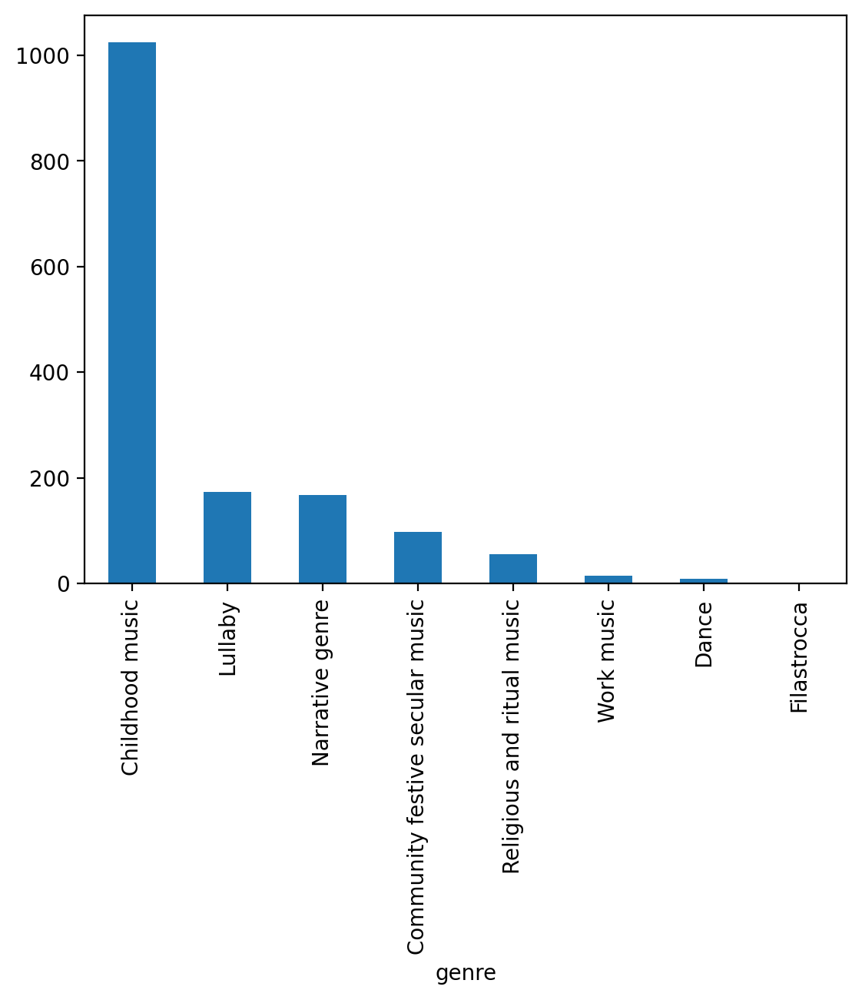

In [ ]:
# @title Show Distributions of Feature In Dataset {"run":"auto","vertical-output":true,"display-mode":"form"}

#@markdown This code block generates descriptive statistics and distributions for various musical and metadata features in the EA-Digifolk dataset.
#@markdown >The user can select both a subset of the dataset and a feature whose distribution will be analyzed.

import statistics

dataset = "all" # @param ["all", "spanish", "portuguese", "mexican", "italian", "colombian", "irish", "miscellaneous"]
feature = "genre" # @param ["range", "number of phrases", "number of notes per phrase", "key", "mode", "key-mode", "meter", "country", "genre", "textual topics"]

import music21 as m21

temp_dataset = filter_country(EADIGIFOLK[~EADIGIFOLK.index.duplicated()].copy(), dataset)

def to_pitch(x):
  try:
    return m21.pitch.Pitch(x.replace(' flat','-'))
  except Exception:
    return None

if feature == 'range':
  temp_df = temp_dataset[['ambitus_highest', 'ambitus_lowest']].copy()
  temp_df['m21_H'] = temp_df['ambitus_highest'].apply(lambda x: to_pitch(x) if isinstance(x, str) else None)
  temp_df['m21_L'] = temp_df['ambitus_lowest'].apply(lambda x: to_pitch(x) if isinstance(x, str) else None)
  temp_df = temp_df.dropna(subset=['m21_H', 'm21_L'])
  temp_df['range'] = temp_df.apply(lambda x: m21.interval.Interval(x['m21_H'], x['m21_L']).name, axis=1)
  display(temp_df['range'].describe())
  display(temp_df['range'].value_counts())
  display(temp_df['range'].value_counts().plot(kind='bar'))
elif feature == 'number of phrases':
  temp_df = temp_dataset[['features']].copy()
  temp_df['phrases'] = temp_df['features'].apply(n_phrases)
  display(temp_df['phrases'].describe())
  display(temp_df['phrases'].value_counts())
  display(temp_df['phrases'].value_counts().plot(kind='bar'))
elif feature == 'number of notes per phrase':
  temp_df = temp_dataset[['features']].copy()
  temp_df['notes_phrases'] = temp_df['features'].apply(mean_notes_per_phrase)
  display(temp_df['notes_phrases'].describe())
  display(temp_df['notes_phrases'].value_counts())
  display(temp_df['notes_phrases'].value_counts().plot(kind='bar'))
elif feature == 'key-mode':
  temp_df = temp_dataset[['key', 'mode']].fillna('').astype(str).copy()
  temp_df['key-mode'] = temp_df[['key','mode']].apply(lambda x: x['key'].capitalize().replace(' ','') + ' ' + x['mode'].capitalize().replace(' ',''), axis=1)
  display(temp_df['key-mode'].describe())
  display(temp_df['key-mode'].value_counts())
  display(temp_df['key-mode'].value_counts().plot(kind='bar'))
elif feature == 'textual topics':
  topics = temp_dataset['textual_topics'].explode().dropna().astype(str).str.capitalize()
  display(topics.describe())
  display(topics.value_counts())
  display(topics.value_counts().plot(kind='bar'))
elif feature in ['key', 'mode', 'meter', 'country', 'genre']:
  values = temp_dataset[feature].dropna().astype(str).str.capitalize()
  display(values.describe())
  display(values.value_counts())
  display(values.value_counts().plot(kind='bar'))


In [ ]:
# @title Search Dataset per Feature {"run":"auto"}

dataset = "all" # @param ["all", "spanish", "portuguese", "mexican", "italian", "colombian", "irish", "miscellaneous"]
feature = "number of phrases" # @param ["range", "number of phrases", "number of notes per phrase", "key", "mode", "key-mode", "meter", "country", "textual topics"]
value = "1" # @param {"type":"string","placeholder":"Lullaby"}

import music21 as m21

temp_dataset = filter_country(EADIGIFOLK.copy(), dataset)

mask = None

if feature == 'range':
  temp_df = temp_dataset[['ambitus_highest', 'ambitus_lowest']].copy()
  temp_df['m21_H'] = temp_df['ambitus_highest'].apply(lambda x: to_pitch(x) if isinstance(x, str) else None)
  temp_df['m21_L'] = temp_df['ambitus_lowest'].apply(lambda x: to_pitch(x) if isinstance(x, str) else None)
  temp_df = temp_df.dropna(subset=['m21_H', 'm21_L'])
  temp_df['range'] = temp_df.apply(lambda x: m21.interval.Interval(x['m21_H'], x['m21_L']).name, axis=1)
  mask = EADIGIFOLK.index.isin(temp_df[temp_df['range'].str.contains(value) == True].index.to_list())
elif feature == 'number of phrases':
  temp_df = temp_dataset[['features']].copy()
  temp_df['phrases'] = temp_df['features'].apply(n_phrases)
  mask = EADIGIFOLK.index.isin(temp_df[temp_df['phrases'] == int(value)].index.to_list())
elif feature == 'number of notes per phrase':
  temp_df = temp_dataset[['features']].copy()
  temp_df['notes_phrases'] = temp_df['features'].apply(mean_notes_per_phrase)
  mask = EADIGIFOLK.index.isin(temp_df[temp_df['notes_phrases'] == int(value)].index.to_list())
elif feature == 'key-mode':
  temp_df = temp_dataset[['key', 'mode']].fillna('').astype(str).copy()
  temp_df['key-mode'] = temp_df[['key','mode']].apply(lambda x: x['key'].capitalize().replace(' ','') + ' ' + x['mode'].capitalize().replace(' ',''), axis=1)
  mask = EADIGIFOLK.index.isin(temp_df[temp_df['key-mode'].str.contains(value) == True].index.to_list())
elif feature == 'textual topics':
  topics = [value] if ';' not in value else value.split('; ')
  has_topic = temp_dataset['textual_topics'].apply(lambda x: isinstance(x, list) and any(t in x for t in topics))
  mask = EADIGIFOLK.index.isin(has_topic[has_topic].index.to_list())
elif feature in ['key', 'mode', 'meter', 'country']:
  mask = EADIGIFOLK.index.isin(temp_dataset[temp_dataset[feature].astype(str).str.contains(value) == True].index.to_list())

display(EADIGIFOLK[mask])
print(f"Number of Rows: {EADIGIFOLK[mask].shape[0]}")


,title,subtitle,compiler,informer,geographic,encoder,editor,source_id,source_title,source_subtitle,source_compiler,source_informer,bibliography,introduction,edition,publisher,publication_place,date,pages,ambitus_lowest,ambitus_highest,pitch_pattern,interval_pattern,rhythm_pattern,phrases,key,mode,meter,tempo,genre,ngram,bigram,textual_topics,has_lyrics?,has_freemeter?,features,mei_id,file,n_voices,country
id,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
IT-1954-FVG-AF-XXXb,Nine-nane,None,Adelgiso Fior,"Girani Petrozzi, Ersilia Gambierasi",Friuli,Marco Bellano,Marco Bellano,to_add,Villotte E Canti Del Friùli,"Antologia Di Canti Friulani, Con Versione In I...",None,None,None,None,None,Edizioni Piva,"Milano (Mi), Italia",1954.0,NaN,f4,e5,None,None,None,"(1, #n1buwm7v, #n60mbpy, A)",F,major,Ternary,None,Lullaby,None,None,[],Vocal,False,"{'id': ['n1buwm7v', 'nre9cyx', 'n47rbsk', 'nnz...",IT-1954-FVG-AF-XXXb,/content/EA-Digifolk-Dataset/Italy/IT-1954-FVG...,1,IT
IT-1981-VEN-VP-060,Oh Quante Belle Figlie Madama Dorè,None,Vere Paiola,None,Vicenza,Marco Bellano,Marco Bellano,to_add,Canti Popolari Vicentini,None,Roberto Leydi,None,None,Neri Pozza,None,Neri Pozza,"Vicenza (Vi), Italia",1981.0,NaN,c4,a4,None,None,None,"(1, #n1an6wbf, #n1h5m0k1, A)",C,major,Binary,Allegro,Childhood Music,None,None,[],Vocal,False,"{'id': ['n1an6wbf', 'nhmuf4x', 'n409fg1', 'n1i...",IT-1981-VEN-VP-060,/content/EA-Digifolk-Dataset/Italy/IT-1981-VEN...,1,IT
IT-1981-VEN-VP-061,Lo Ligheremo,None,Vere Paiola,None,Vicenza,Marco Bellano,Marco Bellano,to_add,Canti Popolari Vicentini,None,Roberto Leydi,None,None,Neri Pozza,None,Neri Pozza,"Vicenza (Vi), Italia",1981.0,NaN,g4,b4,None,None,None,"(1, #n17y2z7, #n1amkbf3, A)",G,major,Ternary,Moderato,Childhood Music,None,None,[],Vocal,False,"{'id': ['n17y2z7', 'no63rb9', 'n1fasu4q', 'nk0...",IT-1981-VEN-VP-061,/content/EA-Digifolk-Dataset/Italy/IT-1981-VEN...,1,IT
IT-1981-VEN-VP-065,Careghete Done,None,Vere Paiola,None,Vicenza,Marco Bellano,Marco Bellano,to_add,Canti Popolari Vicentini,None,Roberto Leydi,None,None,Neri Pozza,None,Neri Pozza,"Vicenza (Vi), Italia",1981.0,NaN,e4,a4,None,None,None,"(1, #n18jgang, #n12k0wvh, A)",C,major,Binary,Andantino,Childhood Music,None,None,[],Vocal,False,"{'id': ['n18jgang', 'n870tcs', 'n1nhzfnm', 'nt...",IT-1981-VEN-VP-065,/content/EA-Digifolk-Dataset/Italy/IT-1981-VEN...,1,IT
IT-1981-VEN-VP-066,Andèmo Alla Guerra,None,Vere Paiola,None,Vicenza,Marco Bellano,Marco Bellano,to_add,Canti Popolari Vicentini,None,Roberto Leydi,None,None,Neri Pozza,None,Neri Pozza,"Vicenza (Vi), Italia",1981.0,NaN,e4,b4,None,None,None,"(1, #nw0v57m, #n1ry61uy, A)",G,protomelodic,Binary,Allegro Moderato,Childhood Music,None,None,[],Vocal,False,"{'id': ['nw0v57m', 'n10bb64d', 'nmp4ye3', 'n1g...",IT-1981-VEN-VP-066,/content/EA-Digifolk-Dataset/Italy/IT-1981-VEN...,1,IT
IT-1999-VEN-GV-017a,Nina Nana,None,Gabriele Vardanega,None,None,Marco Bellano,Marco Bellano,to_add,Canti Del Grappa,Il Canto Popolare Nella Tradizione Orale Della...,Gabriele Vardanega,None,None,Daniele Cunial,Anna Cavarzan,Danilo Zanetti Editore,"Caerano S. Marco (Tv), Italia",1999.0,551.0,b4,e5,None,None,None,"(1, #nu2zkpx, #ngmeo48, A)",C,major,Binary,None,Lullaby,None,None,[],Vocal,False,"{'id': ['nu2zkpx', 'n18nm6an', 'nprry1s', 'n1y...",IT-1999-VEN-GV-017a,/content/EA-Digifolk-Dataset/Italy/IT-1999-VEN...,1,IT
IT-1999-VEN-GV-017b,Nina Nana,None,Gabriele Vardanega,None,None,Marco Bellano,Marco Bellano,to_add,Canti Del Grappa,Il Canto Popolare Nella Tradizione Orale Della...,Gabriele Vardanega,None,None,Daniele Cunial,Anna Cavarzan,Danilo Zanetti Editore,"Caerano S. Marco (Tv), Italia",1999.0,551.0,c4,e4,None,None,None,"(1, #n1nwn1j4, #ntedcsa, A)",C,major,Binary,None,Lullaby,None,None,[],Vocal,False,"{'id': ['n1nwn1j4', 'n122432c', 'ng8b0if', 'nb...",IT-1999-VEN-GV-017b,/content/EA-Digifolk-Dataset/Italy/IT-1999-VEN...,1,IT
ES-1948-CB-CO1-033,33. José se llama el padre; 33. José se llama ...,José se llama el padre,Córdova y Oña,None,None,Sara Gonzá

Number of Rows: 25


### Demos

Axes(0.125,0.11;0.775x0.77)
Number of Binary Lullabies: 67.05202312138728%


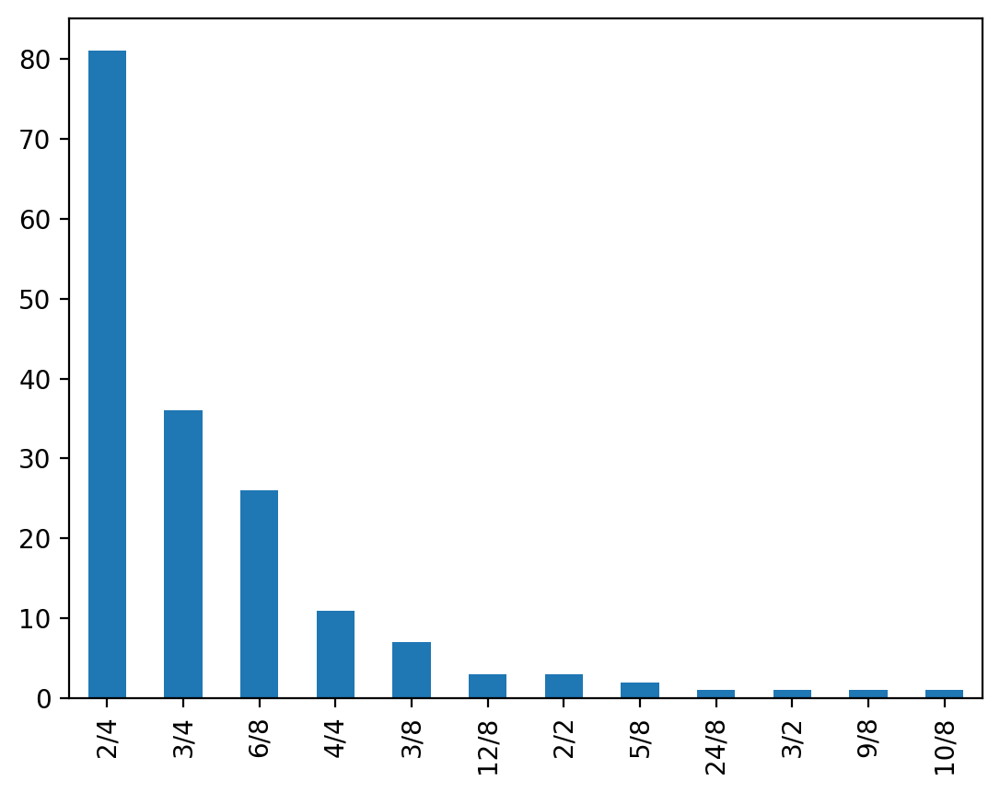

In [ ]:
time_signature_lullabies = EADIGIFOLK[EADIGIFOLK['genre'] == 'Lullaby'].apply(lambda x: x['features']['timesignature'][0], axis=1)
print(time_signature_lullabies.value_counts().plot(kind='bar'))

binary_lullabies = EADIGIFOLK[(EADIGIFOLK['genre'] == 'Lullaby') & (EADIGIFOLK['meter'] == 'Binary')]
total_lullabies = EADIGIFOLK[(EADIGIFOLK['genre'] == 'Lullaby')]
print(f"Number of Binary Lullabies: {(binary_lullabies.shape[0]*100)/total_lullabies.shape[0]}%")

Axes(0.125,0.11;0.775x0.77)
Number of Binary Childhood Music: 50.4390243902439%


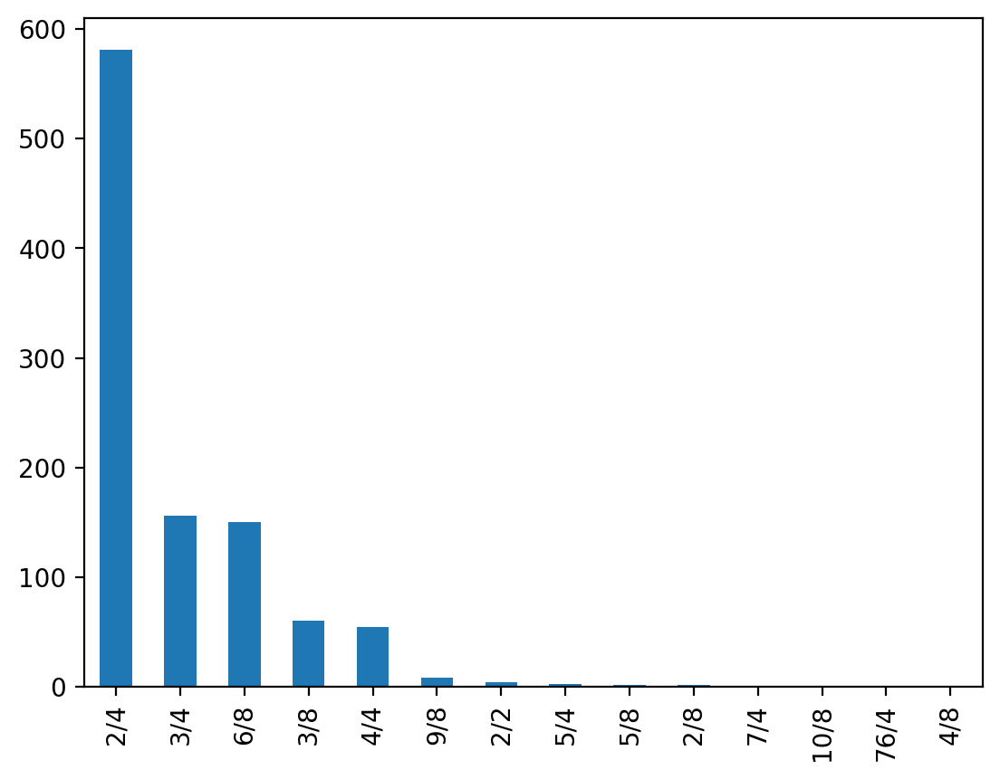

In [ ]:
time_signature_children = EADIGIFOLK[EADIGIFOLK['genre'] == 'Childhood Music'].apply(lambda x: x['features']['timesignature'][0], axis=1)
print(time_signature_children.value_counts().plot(kind='bar'))

binary_children = EADIGIFOLK[(EADIGIFOLK['genre'] == 'Childhood Music') & (EADIGIFOLK['meter'] == 'Binary')]
total_children = EADIGIFOLK[(EADIGIFOLK['genre'] == 'Childhood Music')]
print(f"Number of Binary Childhood Music: {(binary_children.shape[0]*100)/total_children.shape[0]}%")

In [ ]:
display(EADIGIFOLK[(EADIGIFOLK['genre'] == 'Lullaby')]['textual_topics'].explode().str.capitalize().value_counts())
display(EADIGIFOLK[(EADIGIFOLK['genre'] == 'Childhood Music')]['textual_topics'].explode().str.capitalize().value_counts())

,count
textual_topics,


,count
textual_topics,


In [ ]:
display(EADIGIFOLK[(EADIGIFOLK['genre'] == 'Lullaby')]['mode'].str.lower().str.replace(r'[-~!?]', '', regex=True).str.extract(r'(\w+\s\w+[^0-9]|\w+[^0-9])').value_counts())
display(EADIGIFOLK[(EADIGIFOLK['genre'] == 'Childhood Music')]['mode'].str.lower().str.replace(r'[-~!?]', '', regex=True).str.extract(r'(\w+\s\w+[^0-9]|\w+[^0-9])').value_counts())

,count
0,
major,53
phrygian,46
aeolian,31
protomelodic,10
ionian,10
minor,7
mixolydian,4
locrian,2
dorian,2


,count
0,
major,476
aeolian,59
protomelodic,35
phrygian,28
mixolydian,28
minor,22
ionian,20
dorian,4
protomelodicmajor,2


## Phrase Segmentation Analyses

This section answers questions about the dataset that matter for phrase segmentation model.

| # | Question | Section |
|---|---|---|
| 1 | How many files have phrase annotations? Which values appear in `supplied/@type`, `phrase/@type` and `note/@type`? | Q1 |
| 2 | How many phrases overlap, leave gaps, or end before they start? | Q2 |
| 3 | Which features have the most impact on the notes that close a phrase? | Q3 |
| 4 | How many notes per song, with and without unfolding the repeats? | Q4 |
| 5 | How many phrases per song, and how long are they (notes, beats, bars)? | Q5 |
| 6 | Which musical cues announce a phrase boundary? | Q6 |
| 7 | Do all phrases of a song have the same length? | Q7 |
| 8 | Distribution by country and genre | Q8 |
| 9 | Are there duplicated songs? | Q9 |


In [ ]:
#@title Configuration of the analyses
import io, json, pickle, hashlib, warnings, contextlib
from collections import Counter, defaultdict
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from lxml import etree
from tqdm.auto import tqdm

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 60)
pd.set_option('display.width', 200)

# Where results are saved. To keep them between Colab sessions, use Google Drive, e.g.:
#   RESULTS_DIR = '/content/drive/MyDrive/EA-Digifolk-analyses'
RESULTS_DIR = '/content/eda_results'
os.makedirs(RESULTS_DIR, exist_ok=True)

MEI_NS = 'http://www.music-encoding.org/ns/mei'
NS = {'m': MEI_NS}
XML_ID = '{http://www.w3.org/XML/1998/namespace}id'

def save(obj, name, index=True):
    """Save a table (CSV) or the current figure (PNG) to RESULTS_DIR."""
    path = os.path.join(RESULTS_DIR, name)
    if isinstance(obj, (pd.DataFrame, pd.Series)):
        obj.to_csv(path + '.csv', index=index)
    elif obj == 'fig':
        plt.savefig(path + '.png', dpi=150, bbox_inches='tight')
    return path

LOG = []   # text summary of every analysis, written to summary.md at the end
def log(q, text):
    print(text)
    LOG.append((q, text))

as_dict = lambda s: {k: int(v) for k, v in s.items()}

def collection_id(song_id):
    """Songbook = country-year-compiler (the region field varies inside the same book)."""
    p = song_id.split('-')
    return f'{p[0]}-{p[1]}-{p[3]}' if len(p) >= 5 else song_id

import subprocess
commit = subprocess.run(['git', '-C', DATA_DIR, 'log', '-1', '--format=%h %ci'], capture_output=True, text=True).stdout.strip()
log('setup', f'Dataset commit {commit} | {len(DATASET_FILES)} MEI files in {DATASET_FOLDERS} | {datetime.now():%Y-%m-%d %H:%M}')

Dataset commit ac3f8f8 2026-06-30 22:37:06 +0000 | 2414 MEI files in ['Spain', 'Portugal', 'Mexico', 'Italy', 'Colombia', 'Ireland', 'Miscellanous'] | 2026-10-06 13:52


### Reading the MEI files directly (basis for Q1, Q2, Q4, Q8 and Q9)

Each file is read with `lxml` (no music21) and, per song, the following is recorded: annotated phrases, `@type`
values, referenced IDs, repeats/endings, rests, polyphony and dotted ties/slurs. Notes inside `<supplied>`
(rhythm patterns) and `<incip>` are excluded.

In [ ]:
def local(el):
    return etree.QName(el).localname if isinstance(el.tag, str) else None

def inside(el, names):
    p = el.getparent()
    while p is not None:
        if local(p) in names:
            return True
        p = p.getparent()
    return False

def audit_mei(path):
    root = etree.parse(path).getroot()
    body = root.find('.//m:music/m:body', NS)
    sid = song_id_from_path(path)
    r = {'song_id': sid, 'folder': folder_of(path), 'country': country_of(path), 'collection': collection_id(sid),
         'path': path, 'md5': hashlib.md5(open(path, 'rb').read()).hexdigest()}
    if body is None:
        r['error'] = 'no <body>'
        return r

    notes = [n for n in body.iter(f'{{{MEI_NS}}}note') if not inside(n, {'supplied', 'incip'})]
    order = {n.get(XML_ID): i for i, n in enumerate(notes)}
    r['n_notes_written'] = len(notes)
    r['n_rests'] = sum(1 for e in body.iter(f'{{{MEI_NS}}}rest', f'{{{MEI_NS}}}mRest') if not inside(e, {'supplied'}))
    r['n_measures'] = len(body.findall('.//m:measure', NS))
    bars = [m.get('left', '') + ' ' + m.get('right', '') for m in body.findall('.//m:measure', NS)]
    r['has_repeat'] = any('rpt' in b for b in bars)
    r['n_endings'] = len(body.findall('.//m:ending', NS))
    r['n_staves'] = len(root.findall('.//m:staffDef', NS))
    r['max_layers'] = max((len(s.findall('m:layer', NS)) for s in body.findall('.//m:staff', NS)), default=0)
    r['n_chords'] = len(body.findall('.//m:chord', NS))
    r['n_dotted_ties_slurs'] = sum(1 for e in body.iter(f'{{{MEI_NS}}}tie', f'{{{MEI_NS}}}slur') if e.get('lform') == 'dotted')

    # Metadata used in Q8/Q9 (read directly, so files without phrases are included too)
    g = root.find('.//m:work//m:term[@type="genre"]', NS)
    r['genre_raw'] = g.text.strip() if g is not None and g.text and g.text.strip() else None
    t = root.find('.//m:work//m:title[@type="main"]', NS)
    if t is None:
        t = root.find('.//m:titleStmt/m:title[@type="main"]', NS)
    r['title'] = ' '.join(''.join(t.itertext()).split()) if t is not None else None

    # Q1: @type values
    r['note_types'] = dict(Counter(n.get('type') for n in notes if n.get('type')))
    sup = list(body.iter(f'{{{MEI_NS}}}supplied'))
    r['supplied_types_all'] = sorted({str(s.get('type')) for s in sup})
    r['supplied_types_phrases'] = sorted({str(s.get('type')) for s in sup if s.find('m:phrase', NS) is not None})
    phrases = list(body.iter(f'{{{MEI_NS}}}phrase'))
    r['n_phrases'] = len(phrases)
    r['n_phrases_outside_supplied'] = sum(1 for p in phrases if not inside(p, {'supplied'}))
    r['phrase_labels'] = [str(p.get('type')) for p in phrases]
    r['form'] = ''.join(l if len(l) == 1 else f'[{l}]' for l in r['phrase_labels'])

    # Q2: integrity in written order
    starts = [(p.get('startid') or '').lstrip('#') for p in phrases]
    ends = [(p.get('endid') or '').lstrip('#') for p in phrases]
    r['phrase_pairs'] = list(zip(starts, ends, r['phrase_labels']))
    r['n_missing_ids'] = sum(1 for x in starts + ends if x not in order)
    r['n_start_after_end'] = sum(1 for s, e in zip(starts, ends) if s in order and e in order and order[s] > order[e])
    r['n_shared_starts'] = len(starts) - len(set(starts))
    cad = {n.get(XML_ID) for n in notes if n.get('type') in ('R', 'SR')}
    cad_pos = {order[c] for c in cad}
    r['n_cadence_notes'] = len(cad)
    r['n_end_is_cadence'] = sum(1 for e in ends if e in cad)
    r['n_end_next_to_cadence'] = sum(1 for e in ends if e in order and e not in cad and ({order[e] - 1, order[e] + 1} & cad_pos))

    # Gaps and overlaps in written order (only meaningful without repeats)
    if phrases and not (r['has_repeat'] or r['n_endings']) and r['n_missing_ids'] == 0 and r['n_start_after_end'] == 0:
        cov = np.zeros(len(notes), int)
        for s, e in zip(starts, ends):
            cov[order[s]:order[e] + 1] += 1
        r['w_uncovered_notes'] = int((cov == 0).sum())
        r['w_overlap_notes'] = int((cov > 1).sum())
        spans = sorted((order[s], order[e]) for s, e in zip(starts, ends))
        r['w_phrases_overlapping'] = sum(1 for a, b in zip(spans, spans[1:]) if b[0] <= a[1])
        r['w_phrases_gap_after'] = sum(1 for a, b in zip(spans, spans[1:]) if b[0] > a[1] + 1)
    return r

audit_rows = []
for f in tqdm(DATASET_FILES, desc='MEI'):
    try:
        audit_rows.append(audit_mei(f))
    except Exception as e:
        audit_rows.append({'song_id': song_id_from_path(f), 'path': f, 'folder': folder_of(f), 'country': country_of(f),
                           'error': repr(e)[:200]})
audit = pd.DataFrame(audit_rows)
if 'error' not in audit:
    audit['error'] = None
audit['annotated'] = audit['n_phrases'].fillna(0) > 0
log('setup', f"Files read: {len(audit)} | XML read errors / files without <body>: {audit['error'].notna().sum()}")
save(audit.drop(columns=['path', 'phrase_pairs']), 'audit_mei', index=False)
audit.head()

MEI:   0%|          | 0/2414 [00:00<?, ?it/s]

Files read: 2414 | XML read errors / files without <body>: 381


,song_id,folder,country,collection,path,md5,n_notes_written,n_rests,n_measures,has_repeat,n_endings,n_staves,max_layers,n_chords,n_dotted_ties_slurs,genre_raw,title,note_types,supplied_types_all,supplied_types_phrases,n_phrases,n_phrases_outside_supplied,phrase_labels,form,phrase_pairs,n_missing_ids,n_start_after_end,n_shared_starts,n_cadence_notes,n_end_is_cadence,n_end_next_to_cadence,w_uncovered_notes,w_overlap_notes,w_phrases_overlapping,w_phrases_gap_after,error,annotated
0,CO-1935-00-LL-03561,Colombia,CO,CO-1935-LL,/content/EA-Digifolk-Dataset/Colombia/CO-1935-...,799fb48e20a5d3578213360ee6b9f922,22.0,0.0,8.0,False,0.0,1.0,1.0,0.0,0.0,Childhood Music,Nana,{},[],[],0.0,0.0,[],,[],0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,False
1,CO-1935-00-LL-03562,Colombia,CO,CO-1935-LL,/content/EA-Digifolk-Dataset/Colombia/CO-1935-...,ef70346e52a427d5e1108e0c97831b0c,23.0,3.0,4.0,False,0.0,1.0,1.0,0.0,0.0,Childhood Music,La lluvia,{},[],[],0.0,0.0,[],,[],0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,False
2,CO-1935-00-LL-03563,Colombia,CO,CO-1935-LL,/content/EA-Digifolk-Dataset/Colombia/CO-1935-...,cecdb12419dc4d785e41c06c97e3475e,25.0,4.0,16.0,False,0.0,1.0,1.0,0.0,0.0,Childhood Music,Ave Maris Stella,{},[],[],0.0,0.0,[],,[],0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,False
3,CO-1935-00-LL-03564,Colombia,CO,CO-1935-LL,/content/EA-Digifolk-Dataset/Colombia/CO-1935-...,b552dd1846db664a25abf4ebf0604155,31.0,4.0,9.0,False,0.0,1.0,1.0,0.0,0.0,Childhood Music,El turpial,{},[],[],0.0,0.0,[],,[],0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,False
4,CO-1935-00-LL-03565,Colombia,CO,CO-1935-LL,/content/EA-Digifolk-Dataset/Colombia/CO-1935-...,a6ad6cd0386ad8c114a65376d632888c,22.0,1.0,9.0,False,0.0,1.0,1.0,0.0,0.0,Childhood Music,¿Qué haces tú?,{},[],[],0.0,0.0,[],,[],0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,False


### Q1. How many files have phrase annotations? Which values appear in `supplied/@type`, `phrase/@type` and `note/@type`?

According to Carvalho et al. (2021), `phrase/@type` labels the melodic material (A, B, …, CODA) and `note/@type`
marks the cadence type on the last note of a phrase: **R** (resting, conclusive) and **SR** (semi-resting, suspensive).

files  with_phrases  phrases  with_R_SR_cadences  phrases_outside_supplied  %_with_phrases
folder       country                                                                                             
Colombia     CO         92.0           0.0      0.0                 0.0                       0.0             0.0
Ireland      IE        189.0           0.0      0.0                 0.0                       0.0             0.0
             IR          6.0           0.0      0.0                 0.0                       0.0             0.0
Italy        IT         60.0          50.0    123.0                51.0                       0.0            83.3
Mexico       MX        565.0           0.0      0.0                 0.0                       0.0             0.0
Miscellanous MI         61.0           0.0      0.0                 0.0                       0.0             0.0
Portugal     PT         59.0          59.0    335.0                33.0                       0.0           100.0
Spain        ES       1382.0         530.0   2417.0               531.0                       0.0            38.4
TOTAL                 2414.0         639.0   2875.0               615.0                       0.0            26.5

Files with annotated phrases: 639 of 2414 (26.5%) | total phrases: 2875

### supplied/@type (all <supplied> elements)


,files
value,
phrases,831
rythymn pattern,789
rhythm pattern,59
None,2



### supplied/@type of <supplied> elements containing phrases


,files
value,
phrases,637
None,2



### phrase/@type


,phrases
value,
A,1350
B,632
A2,419
CODA,190
C,74
B2,74
D,33
A3,27
B1,14



### note/@type


,notes,files
value,,
mscore-beam-begin,5015,206
mscore-beam-mid,3808,157
mscore-beam-none,2205,206
R,1092,605
SR,388,287
start,115,57
end,64,46
E,1,1


supplied/@type (all): {'phrases': 831, 'rythymn pattern': 789, 'rhythm pattern': 59, 'None': 2}
supplied/@type with phrases: {'phrases': 637, 'None': 2}
phrase/@type (top 15): {'A': 1350, 'B': 632, 'A2': 419, 'CODA': 190, 'C': 74, 'B2': 74, 'D': 33, 'A3': 27, 'B1': 14, 'INTRO': 12, 'A1': 11, 'C2': 10, 'A4': 7, 'C1': 6, 'CODA2': 3}
note/@type: {'mscore-beam-begin': 5015, 'mscore-beam-mid': 3808, 'mscore-beam-none': 2205, 'R': 1092, 'SR': 388, 'start': 115, 'end': 64, 'E': 1}


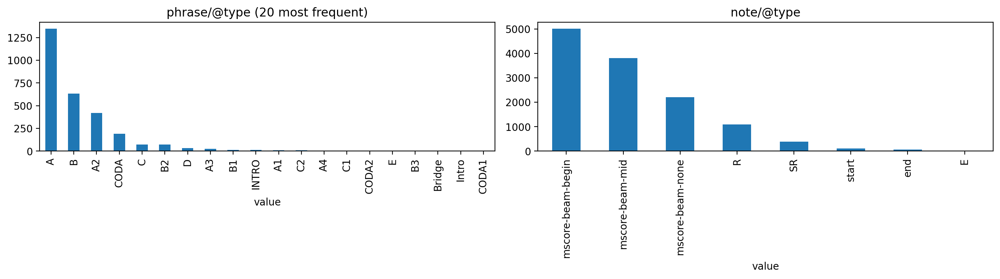

In [ ]:
q1 = audit.groupby(['folder', 'country']).agg(
    files=('song_id', 'size'),
    with_phrases=('annotated', 'sum'),
    phrases=('n_phrases', 'sum'),
    with_R_SR_cadences=('n_cadence_notes', lambda x: int((x.fillna(0) > 0).sum())),
    phrases_outside_supplied=('n_phrases_outside_supplied', 'sum'))
q1['%_with_phrases'] = (100 * q1['with_phrases'] / q1['files']).round(1)
q1.loc[('TOTAL', ''), :] = q1.sum(numeric_only=True)
q1.loc[('TOTAL', ''), '%_with_phrases'] = round(100 * q1.loc[('TOTAL', ''), 'with_phrases'] / q1.loc[('TOTAL', ''), 'files'], 1)
display(q1)
save(q1, 'Q1_coverage_by_folder')

A = audit[audit['annotated']].copy()
log('Q1', f"Files with annotated phrases: {len(A)} of {len(audit)} ({100*len(A)/len(audit):.1f}%) | total phrases: {int(A['n_phrases'].sum())}")

def value_counts_of_lists(series, name):
    c = Counter(v for vals in series.dropna() for v in vals)
    return pd.Series(c, name=name, dtype=int).sort_values(ascending=False).rename_axis('value').to_frame()

sup_all = value_counts_of_lists(audit['supplied_types_all'], 'files')
sup_ph = value_counts_of_lists(audit['supplied_types_phrases'], 'files')
ph_types = value_counts_of_lists(A['phrase_labels'], 'phrases')
note_types = pd.Series(sum((Counter(d) for d in audit['note_types'].dropna()), Counter()), name='notes', dtype=int).sort_values(ascending=False).rename_axis('value').to_frame()
note_types['files'] = [int(audit['note_types'].dropna().map(lambda d, v=v: v in d).sum()) for v in note_types.index]

for title, t, name in [('supplied/@type (all <supplied> elements)', sup_all, 'Q1_supplied_type_all'),
                       ('supplied/@type of <supplied> elements containing phrases', sup_ph, 'Q1_supplied_type_phrases'),
                       ('phrase/@type', ph_types, 'Q1_phrase_type'),
                       ('note/@type', note_types, 'Q1_note_type')]:
    print(f'\n### {title}'); display(t.head(40)); save(t, name)

log('Q1', f"supplied/@type (all): {as_dict(sup_all['files'])}")
log('Q1', f"supplied/@type with phrases: {as_dict(sup_ph['files'])}")
log('Q1', f"phrase/@type (top 15): {as_dict(ph_types['phrases'].head(15))}")
log('Q1', f"note/@type: {as_dict(note_types['notes'])}")

fig, ax = plt.subplots(1, 2, figsize=(14, 4))
ph_types['phrases'].head(20).plot.bar(ax=ax[0], title='phrase/@type (20 most frequent)')
note_types['notes'].plot.bar(ax=ax[1], title='note/@type')
plt.tight_layout(); save('fig', 'Q1_types'); plt.show()

### Note-level table (basis for Q2–Q7 and Q9)

The note features come from `EADIGIFOLK` (the `MeiParser` unfolds repeats with music21 and computes MTC features).
Only the first voice (the melody) of each annotated song is used.

**Labels.** The main label `y` is computed directly from the MEI phrases over the unfolded sequence: for each
occurrence of a `startid`, the phrase closes at the nearest `endid` of a phrase with that start, and that note gets
`y = 1`; the last note of the song too. This way labels exist even when the parser fails on the phrase part.
For comparison, `y_parser` (the parser's `phrase_end`, which marks every occurrence of any `endid`) and `y_ix`
(last note before the parser's `phrase_ix` changes) are also kept. Q2 compares the three.

In [ ]:
FEATS = ['id', 'midipitch', 'pitch', 'scaledegree', 'chromaticinterval', 'diatonicinterval', 'contour3', 'contour5',
         'pitchproximity', 'pitchreversal', 'duration', 'durationcontour', 'nextisrest', 'restduration_frac',
         'timesignature', 'beat', 'beatstrength', 'metriccontour', 'posinbar', 'ima', 'ima_contour',
         'phrase_ix', 'phrase_end', 'ioi', 'ior', 'gpr2a_Frankland', 'gpr2b_Frankland', 'gpr3a_Frankland',
         'gpr3d_Frankland', 'gpr_Frankland_sum', 'lbdm_rpitch', 'lbdm_rioi', 'lbdm_rrest', 'lbdm_boundarystrength', 'lyrics']

# Features per song (first voice) from the EADIGIFOLK dataframe, keyed by the file's song ID
parsed = {}
for _, row in EADIGIFOLK.iterrows():
    if 'file' not in row or not isinstance(row['file'], str):
        continue
    sid = song_id_from_path(row['file'])
    if sid in parsed or row.get('voice', 'v1') != 'v1':
        continue
    parsed[sid] = {'meta': row.drop(labels=['features']).to_dict(), 'features': dict(row['features'])}
n_voices = EADIGIFOLK.set_index('file')['n_voices'].rename(lambda f: song_id_from_path(f)) if 'n_voices' in EADIGIFOLK else pd.Series(dtype=int)
missing = sorted(set(A['song_id']) - set(parsed))
log('setup', f'Annotated songs with note features: {len(set(A.song_id) & set(parsed))} of {len(A)} '
             f'({len(missing)} missing: parser errors, see PARSE_ERRORS / the "Process Dataset" output)')

def unfolded_coverage(ids, pairs):
    """For each occurrence of a startid, close the phrase at the nearest endid of a phrase with that start."""
    ids = list(ids)
    n = len(ids)
    cov = np.zeros(n, int)
    pos = defaultdict(list)
    for i, x in enumerate(ids):
        pos[x].append(i)
    ends_by_start = defaultdict(set)
    for s, e, _ in pairs:
        ends_by_start[s].add(e)
    n_open, n_found, spans = 0, 0, []
    for s, ends in ends_by_start.items():
        end_pos = sorted(p for e in ends for p in pos.get(e, []))
        for i in pos.get(s, []):
            j = next((p for p in end_pos if p >= i), None)
            if j is None:
                n_open += 1; continue
            cov[i:j + 1] += 1; spans.append((i, j)); n_found += 1
    spans.sort()
    return spans, {'u_phrase_occurrences': n_found, 'u_unclosed': n_open,
                   'u_uncovered_notes': int((cov == 0).sum()), 'u_overlap_notes': int((cov > 1).sum()),
                   'u_phrases_overlapping': sum(1 for a, b in zip(spans, spans[1:]) if b[0] <= a[1]),
                   'u_phrases_gap_after': sum(1 for a, b in zip(spans, spans[1:]) if b[0] > a[1] + 1),
                   'u_notes_before_first': spans[0][0] if spans else n,
                   'u_notes_after_last': (n - 1 - max(b for _, b in spans)) if spans else n}

def labels_from_spans(n, spans):
    y = np.zeros(n, int)
    for _, j in spans:
        y[j] = 1
    if n:
        y[-1] = 1
    return y

def labels_from_phrase_ix(phrase_ix):
    ix = np.asarray(phrase_ix)
    y = np.zeros(len(ix), int)
    if len(ix):
        y[:-1] = ix[1:] != ix[:-1]
        y[-1] = 1
    return y

pairs = audit.set_index('song_id')['phrase_pairs']
rows, skipped, unf_stats = [], [], {}
for sid in A['song_id']:
    if sid not in parsed:
        continue
    F = parsed[sid]['features']
    n = len(F.get('id', []))
    keys = [k for k in FEATS if k in F and len(F[k]) == n]
    spans, stats = unfolded_coverage(F.get('id', []), pairs.get(sid, []))
    if n == 0 or not spans:
        skipped.append(sid); continue
    unf_stats[sid] = stats
    df = pd.DataFrame({k: F[k] for k in keys})
    df.insert(0, 'song_id', sid)
    df.insert(1, 'pos', np.arange(n))
    df['y'] = labels_from_spans(n, spans)
    df['y_parser'] = df['phrase_end'].fillna(False).astype(bool).astype(int) if 'phrase_end' in df else np.nan
    df['y_ix'] = labels_from_phrase_ix(df['phrase_ix']) if 'phrase_ix' in df else np.nan
    rows.append(df)
notes = pd.concat(rows, ignore_index=True)
for c in ['duration', 'beat', 'beatstrength', 'posinbar', 'ioi', 'ior', 'midipitch', 'scaledegree', 'chromaticinterval',
          'diatonicinterval', 'pitchproximity', 'pitchreversal', 'ima'] + [c for c in notes if c.startswith(('gpr', 'lbdm'))]:
    if c in notes:
        notes[c] = pd.to_numeric(notes[c], errors='coerce')

def bar_quarters(ts):
    try:
        n, d = map(int, str(ts).split('/')); return n * 4 / d
    except Exception:
        return np.nan

def beat_unit_quarters(ts):
    """Beat unit in quarter notes: the denominator; in compound meters (6/8, 9/8, 12/8) the beat is a dotted quarter."""
    try:
        n, d = map(int, str(ts).split('/'))
        return 3 * 4 / d if (n % 3 == 0 and n > 3 and d >= 8) else 4 / d
    except Exception:
        return np.nan

notes['bar_q'] = notes['timesignature'].map(bar_quarters)
notes['beat_q'] = notes['timesignature'].map(beat_unit_quarters)
g = notes.groupby('song_id')
notes['is_last'] = notes['pos'] == g['pos'].transform('max')
# the parser's 'ioi' = time to the next onset (includes rests); on the last note the duration is used
notes['span_q'] = notes['ioi'].fillna(notes['duration'])

first_lyric = lambda l: l[0] if isinstance(l, (list, tuple)) and len(l) else None
notes['syl'] = notes['lyrics'].map(lambda l: first_lyric(l)[1] if first_lyric(l) else None) if 'lyrics' in notes else None
notes['syllabic'] = notes['lyrics'].map(lambda l: first_lyric(l)[2] if first_lyric(l) else None) if 'lyrics' in notes else None
notes['has_syl'] = notes['syl'].notna()

songs = notes.groupby('song_id').agg(n_notes_unfolded=('pos', 'size'), n_phrases_unfolded=('y', 'sum'),
                                     n_parser_ends=('y_parser', 'sum'))
songs['parser_has_phrases'] = notes.groupby('song_id')['y_ix'].apply(lambda s: s.notna().all())
songs = songs.join(pd.DataFrame(unf_stats).T.apply(pd.to_numeric))
songs = songs.join(audit.set_index('song_id')[['folder', 'country', 'collection', 'title', 'genre_raw', 'n_notes_written',
                                                'n_phrases', 'form', 'has_repeat', 'n_endings']])
songs['n_voices'] = n_voices.reindex(songs.index).fillna(1).astype(int)
log('setup', f'Note table: {len(notes)} notes in {len(songs)} songs | {len(skipped)} songs with no locatable phrase skipped | '
             f"parser without phrase features in {int((~songs.parser_has_phrases).sum())} songs (labels computed from the MEI)")

Annotated songs with note features: 638 of 639 (1 missing: parser errors, see PARSE_ERRORS / the "Process Dataset" output)
Note table: 46327 notes in 631 songs | 7 songs with no locatable phrase skipped | parser without phrase features in 106 songs (labels computed from the MEI)


### Q2. How many phrases overlap, leave gaps, or end before they start?

**(a) Written order (score, not unfolded).** Counts missing IDs, phrases whose end comes before their start
(usually phrases that cross a repeat) and phrases sharing the same `startid`. Gaps and overlaps are only computed
for songs **without** repeats, where written order equals sung order.

**(b) Unfolded order (as sung).** Each occurrence of a `startid` closes at the nearest `endid` of a phrase with that
start. Counts uncovered notes, notes covered by two phrases, and phrases that never close.

**(c) Labels.** Compares the main label `y` with the parser's `phrase_end` and with the label derived from `phrase_ix`.

In [ ]:
# (a) written order
checks = {
    'phrase IDs not found in the score': A['n_missing_ids'] > 0,
    'phrase ends before it starts': A['n_start_after_end'] > 0,
    'phrases sharing the same startid': A['n_shared_starts'] > 0,
    'has repeats/endings': A['has_repeat'] | (A['n_endings'] > 0),
    'no repeats: notes outside any phrase (gaps)': A['w_uncovered_notes'] > 0,
    'no repeats: notes in 2+ phrases (overlaps)': A['w_overlap_notes'] > 0,
}
q2a = pd.DataFrame({'songs': {k: int(v.sum()) for k, v in checks.items()}})
q2a['% of annotated'] = (100 * q2a['songs'] / len(A)).round(1)
q2a_ph = pd.Series({
    'phrases (total)': int(A['n_phrases'].sum()),
    'phrases with a missing ID (start or end)': int(A['n_missing_ids'].sum()),
    'phrases ending before they start': int(A['n_start_after_end'].sum()),
    'phrases sharing their startid with another': int(A['n_shared_starts'].sum()),
    'no repeats: phrases overlapping the next one': int(A['w_phrases_overlapping'].sum()),
    'no repeats: phrases with a gap before the next one': int(A['w_phrases_gap_after'].sum()),
    'endid is the note marked R/SR': int(A['n_end_is_cadence'].sum()),
    'endid is next to the note marked R/SR': int(A['n_end_next_to_cadence'].sum()),
}, name='phrases').to_frame()
display(q2a); display(q2a_ph)
save(q2a, 'Q2a_songs_written_order'); save(q2a_ph, 'Q2a_phrases_written_order')
for k, v in q2a['songs'].items():
    log('Q2', f'[written] {k}: {v} songs')
for k, v in q2a_ph['phrases'].items():
    log('Q2', f'[written] {k}: {v}')

# (b) unfolded order
unf = songs[[c for c in songs if c.startswith('u_')]]
q2b = pd.DataFrame({
    'songs': {'notes outside any phrase (gaps)': int((unf.u_uncovered_notes > 0).sum()),
              'notes before the first phrase': int((unf.u_notes_before_first > 0).sum()),
              'notes after the last phrase': int((unf.u_notes_after_last > 0).sum()),
              'notes in 2+ phrases (overlaps)': int((unf.u_overlap_notes > 0).sum()),
              'phrases that never close': int((unf.u_unclosed > 0).sum())},
    'total (notes or phrases)': {'notes outside any phrase (gaps)': int(unf.u_uncovered_notes.sum()),
                                 'notes before the first phrase': int(unf.u_notes_before_first.sum()),
                                 'notes after the last phrase': int(unf.u_notes_after_last.sum()),
                                 'notes in 2+ phrases (overlaps)': int(unf.u_overlap_notes.sum()),
                                 'phrases that never close': int(unf.u_unclosed.sum())}})
q2b['% songs'] = (100 * q2b['songs'] / len(unf)).round(1)
display(q2b); save(q2b, 'Q2b_unfolded_order')
log('Q2', f"[unfolded] phrase occurrences: {int(unf.u_phrase_occurrences.sum())} | overlapping the next: {int(unf.u_phrases_overlapping.sum())} | "
          f"gap before the next: {int(unf.u_phrases_gap_after.sum())} | never close: {int(unf.u_unclosed.sum())}")

# (c) main label y vs parser phrase_end vs label derived from phrase_ix
P = notes[songs.loc[notes.song_id, 'parser_has_phrases'].values]
P = P.assign(_prev=P.groupby('song_id')['y_parser'].shift(1).fillna(0))
adj = P[(P.y_parser == 1) & (P._prev == 1)].groupby('song_id').size()
q2c = pd.Series({'songs with parser phrase features': P.song_id.nunique(),
                 'songs with two consecutive ends (phrase_end)': len(adj),
                 'songs where phrase_end != y': int(P[P.y != P.y_parser].song_id.nunique()),
                 'songs where y_ix != y': int(P[P.y != P.y_ix].song_id.nunique()),
                 'ends in y': int(P.y.sum()), 'ends in phrase_end': int(P.y_parser.sum()), 'ends in y_ix': int(P.y_ix.sum())},
                name='value').to_frame()
display(q2c); save(q2c, 'Q2c_labels')
for k, v in q2c['value'].items():
    log('Q2', f'[labels] {k}: {v}')

cols = ['n_phrases', 'form', 'has_repeat', 'u_uncovered_notes', 'u_overlap_notes', 'u_unclosed', 'n_phrases_unfolded']
problem = songs[(songs.u_uncovered_notes > 0) | (songs.u_overlap_notes > 0) | (songs.u_unclosed > 0)]
print('Songs to inspect manually:'); display(problem[cols].sort_values('u_overlap_notes', ascending=False).head(15))
save(problem[cols], 'Q2_songs_to_inspect')

,songs,% of annotated
phrase IDs not found in the score,144,22.5
phrase ends before it starts,228,35.7
phrases sharing the same startid,367,57.4
has repeats/endings,402,62.9
no repeats: notes outside any phrase (gaps),15,2.3
no repeats: notes in 2+ phrases (overlaps),2,0.3


,phrases
phrases (total),2875
phrases with a missing ID (start or end),238
phrases ending before they start,352
phrases sharing their startid with another,973
no repeats: phrases overlapping the next one,3
no repeats: phrases with a gap before the next one,8
endid is the note marked R/SR,2113
endid is next to the note marked R/SR,33


[written] phrase IDs not found in the score: 144 songs
[written] phrase ends before it starts: 228 songs
[written] phrases sharing the same startid: 367 songs
[written] has repeats/endings: 402 songs
[written] no repeats: notes outside any phrase (gaps): 15 songs
[written] no repeats: notes in 2+ phrases (overlaps): 2 songs
[written] phrases (total): 2875
[written] phrases with a missing ID (start or end): 238
[written] phrases ending before they start: 352
[written] phrases sharing their startid with another: 973
[written] no repeats: phrases overlapping the next one: 3
[written] no repeats: phrases with a gap before the next one: 8
[written] endid is the note marked R/SR: 2113
[written] endid is next to the note marked R/SR: 33


,songs,total (notes or phrases),% songs
notes outside any phrase (gaps),122,2071,19.3
notes before the first phrase,12,287,1.9
notes after the last phrase,89,1393,14.1
notes in 2+ phrases (overlaps),36,988,5.7
phrases that never close,49,50,7.8


[unfolded] phrase occurrences: 2589 | overlapping the next: 64 | gap before the next: 54 | never close: 50


,value
songs with parser phrase features,525
songs with two consecutive ends (phrase_end),12
songs where phrase_end != y,51
songs where y_ix != y,57
ends in y,2216
ends in phrase_end,2214
ends in y_ix,2197


[labels] songs with parser phrase features: 525
[labels] songs with two consecutive ends (phrase_end): 12
[labels] songs where phrase_end != y: 51
[labels] songs where y_ix != y: 57
[labels] ends in y: 2216
[labels] ends in phrase_end: 2214
[labels] ends in y_ix: 2197
Songs to inspect manually:


,n_phrases,form,has_repeat,u_uncovered_notes,u_overlap_notes,u_unclosed,n_phrases_unfolded
song_id,,,,,,,
ES-1948-CB-CO1-217,12.0,[INTRO]AA[A2][A2][A2]BB[B2][B2][B2][B2],True,0,214,0,11
IT-1973-IT-RL-008,4.0,AABB,True,0,76,0,2
ES-1948-CB-CO1-006,6.0,AA[A2][A2][A2]A,True,0,68,0,8
ES-1948-CB-CO1-103,3.0,AAA,True,0,60,0,3
ES-1948-CB-CO1-110,8.0,AAAA[A2][A2][A2][A2],True,16,50,1,4
ES-1948-CB-CO1-032,6.0,AAAABB,True,22,49,1,4
ES-1948-CB-CO1-017,6.0,ABBABB,True,3,45,1,6
ES-1948-CB-CO1-295,10.0,AABBAABB[A2][A2],True,65,40,0,6
IT-1999-VEN-GV-027,4.0,AB[CODA][CODA],True,48,34,0,1


'/content/eda_results/Q2_songs_to_inspect'

### Q4. How many notes per song, with and without unfolding the repeats?
TransPhrase uses a padding length of 300 notes; the table shows how many songs fit entirely.

,n_notes_written,n_notes_unfolded
count,631.0,631.0
mean,48.8,73.4
std,38.6,53.2
min,5.0,5.0
25%,32.0,44.5
50%,39.0,62.0
75%,57.0,84.0
90%,80.0,122.0
95%,102.5,148.5
99%,134.4,271.2


,n_notes_written_median,n_notes_unfolded_median
country,,
ES,40.0,62.0
IT,36.0,39.0
PT,40.0,80.0


,128,256,300,512
% songs with <= L notes,,,,
unfolded,91.6,98.6,99.2,99.8
written,97.8,99.7,99.7,99.8


Notes/song written: median 39, max 692 | unfolded: median 62, max 692 | 395 songs change when unfolded | <=300 notes: 99.2% (unfolded)


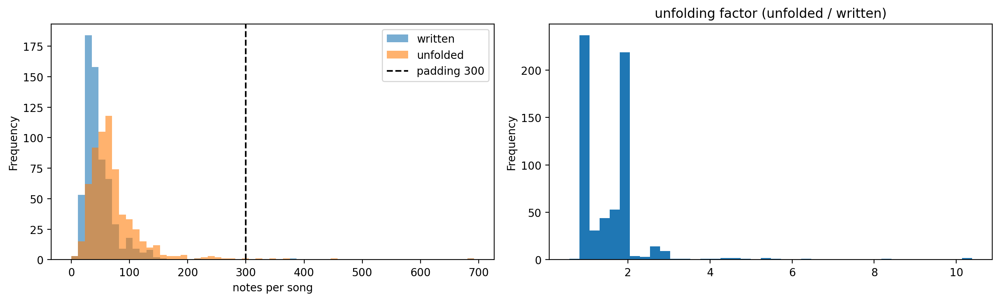

In [ ]:
songs['unfold_factor'] = songs['n_notes_unfolded'] / songs['n_notes_written']
q4 = songs[['n_notes_written', 'n_notes_unfolded']].describe(percentiles=[.25, .5, .75, .9, .95, .99]).round(1)
display(q4); save(q4, 'Q4_notes_per_song')
q4_country = songs.groupby('country')[['n_notes_written', 'n_notes_unfolded']].median()
display(q4_country.rename(columns=lambda c: c + '_median')); save(q4_country, 'Q4_notes_per_song_by_country')
pad = pd.DataFrame({L: {'unfolded': 100 * (songs.n_notes_unfolded <= L).mean(), 'written': 100 * (songs.n_notes_written <= L).mean()}
                    for L in [128, 256, 300, 512]}).round(1)
pad.index.name = '% songs with <= L notes'
display(pad); save(pad, 'Q4_padding')
log('Q4', f"Notes/song written: median {songs.n_notes_written.median():.0f}, max {songs.n_notes_written.max():.0f} | "
          f"unfolded: median {songs.n_notes_unfolded.median():.0f}, max {songs.n_notes_unfolded.max():.0f} | "
          f"{(songs.unfold_factor > 1.01).sum()} songs change when unfolded | <=300 notes: {pad.loc['unfolded', 300]}% (unfolded)")

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
bins = np.linspace(0, songs[['n_notes_written', 'n_notes_unfolded']].max().max(), 60)
songs['n_notes_written'].plot.hist(bins=bins, ax=ax[0], alpha=.6, label='written')
songs['n_notes_unfolded'].plot.hist(bins=bins, ax=ax[0], alpha=.6, label='unfolded')
ax[0].axvline(300, color='k', ls='--', label='padding 300'); ax[0].legend(); ax[0].set_xlabel('notes per song')
songs['unfold_factor'].plot.hist(bins=40, ax=ax[1], title='unfolding factor (unfolded / written)')
plt.tight_layout(); save('fig', 'Q4_notes_per_song'); plt.show()

### Q5. How many phrases per song, and how long are they (notes, beats, bars)?
- **Annotated phrases**: `<phrase>` elements in the MEI (the melody's template form).
- **Sung phrases**: phrases in the unfolded sequence (label `y`), which is what the model will see.
- Length in **quarter notes**, **beats** (beat unit of the meter; in 6/8, 9/8 and 12/8 the beat is a dotted quarter)
  and **bars**, summing each note's inter-onset interval (internal rests included).

,annotated phrases,sung phrases (unfolded)
count,631.00,631.00
mean,4.53,4.17
std,3.00,3.49
min,1.00,1.00
25%,3.00,2.00
50%,4.00,4.00
75%,6.00,4.00
max,41.00,44.00


,n_notes,quarters,beats,bars
count,2631.00,2631.00,2631.00,2631.00
mean,17.61,12.15,12.39,5.28
std,9.27,6.59,7.22,2.89
min,1.00,0.50,0.50,0.22
5%,7.00,4.00,4.00,2.00
25%,12.00,8.00,8.00,4.00
50%,16.00,11.00,10.00,4.00
75%,22.00,16.00,16.00,7.00
95%,34.00,24.00,24.00,10.00
max,109.00,70.50,107.00,35.67


,n_notes,beats,bars
country,,,
ES,16.0,12.00,4.25
IT,18.0,12.67,4.00
PT,14.0,8.00,4.00


Annotated phrases/song: median 4 | sung: median 4
Phrase length: median 16 notes, 10.0 beats, 4.0 bars | phrases with a whole number of bars: 68.1% | with 2 or 4 bars: 41.0%
Share of notes that end a phrase: 5.68% (~1 in 17.6) -> suggested positive-class weight ~ 16.6


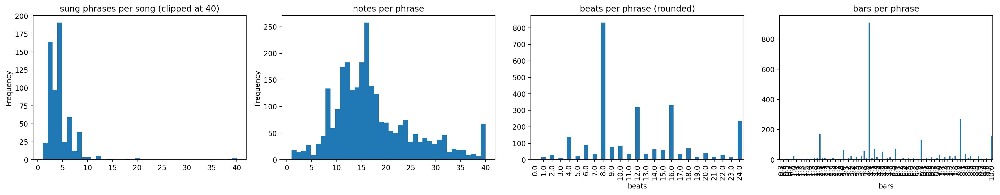

In [ ]:
notes['phrase_id'] = notes.groupby('song_id')['y'].transform(lambda s: s.shift(1).fillna(0).cumsum()).astype(int)
ph = notes.groupby(['song_id', 'phrase_id']).agg(
    n_notes=('pos', 'size'), quarters=('span_q', 'sum'), bar_q=('bar_q', 'first'), beat_q=('beat_q', 'first'),
    ts=('timesignature', 'first'), start_posinbar=('posinbar', 'first'), n_syl=('has_syl', 'sum'),
    end_scaledegree=('scaledegree', 'last'))
ph['beats'] = ph['quarters'] / ph['beat_q']
ph['bars'] = ph['quarters'] / ph['bar_q']
ph = ph.join(songs[['country', 'folder']], on='song_id')

q5_counts = pd.DataFrame({'annotated phrases': songs['n_phrases'].describe(), 'sung phrases (unfolded)': songs['n_phrases_unfolded'].describe()}).round(2)
q5_len = ph[['n_notes', 'quarters', 'beats', 'bars']].describe(percentiles=[.05, .25, .5, .75, .95]).round(2)
display(q5_counts); display(q5_len)
save(q5_counts, 'Q5_phrases_per_song'); save(q5_len, 'Q5_phrase_length')
q5_country = ph.groupby('country')[['n_notes', 'beats', 'bars']].describe().round(2)
display(ph.groupby('country')[['n_notes', 'beats', 'bars']].median().round(2)); save(q5_country, 'Q5_phrase_length_by_country')
bars_r = ph['bars'].round(2)
log('Q5', f"Annotated phrases/song: median {songs.n_phrases.median():.0f} | sung: median {songs.n_phrases_unfolded.median():.0f}")
log('Q5', f"Phrase length: median {ph.n_notes.median():.0f} notes, {ph.beats.median():.1f} beats, {ph.bars.median():.1f} bars | "
          f"phrases with a whole number of bars: {100*(bars_r == bars_r.round()).mean():.1f}% | with 2 or 4 bars: {100*bars_r.isin([2, 4]).mean():.1f}%")
rate = notes['y'].mean()
log('Q5', f'Share of notes that end a phrase: {100*rate:.2f}% (~1 in {1/rate:.1f}) -> suggested positive-class weight ~ {(1-rate)/rate:.1f}')

fig, ax = plt.subplots(1, 4, figsize=(20, 4))
songs['n_phrases_unfolded'].clip(upper=40).plot.hist(bins=40, ax=ax[0], title='sung phrases per song (clipped at 40)')
ph['n_notes'].clip(upper=40).plot.hist(bins=40, ax=ax[1], title='notes per phrase')
ph['beats'].round().clip(upper=24).value_counts().sort_index().plot.bar(ax=ax[2], title='beats per phrase (rounded)')
ph['bars'].round(1).clip(upper=10).value_counts().sort_index().plot.bar(ax=ax[3], title='bars per phrase')
plt.tight_layout(); save('fig', 'Q5_phrases'); plt.show()

### Q7. Do all phrases of a song have the same length?
Coefficient of variation (std / mean) of phrase length within each song, on the unfolded sequence.
The **last** phrase can be longer because of the final held note, so the check is also done without it.

,n_notes,beats,bars
% songs with all phrases equal,25.987,31.250,31.086
% equal ignoring the last phrase,25.225,40.315,40.315
median CV,0.091,0.059,0.059


,equal_n_notes,equal_beats,equal_bars
country,,,
ES,29.3,32.2,32.0
IT,12.5,15.0,15.0
PT,6.8,33.9,33.9


Songs with all phrases equal - notes: 26.0%, beats: 31.2%, bars: 31.1% | median CV (notes): 0.091


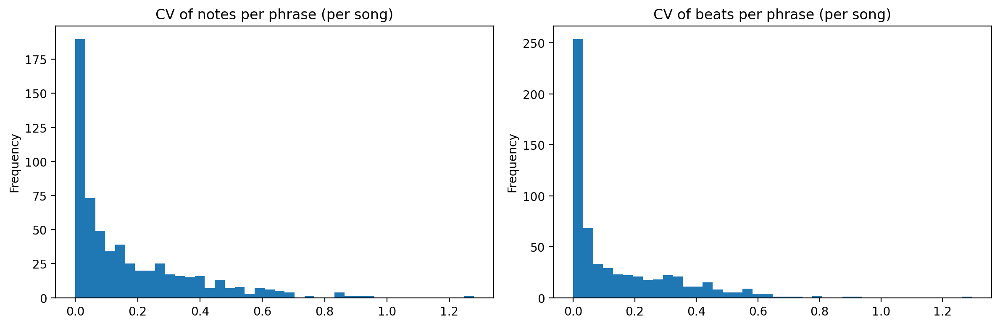

In [ ]:
def regularity(d):
    out = {}
    for col in ['n_notes', 'beats', 'bars']:
        x = d[col].values
        out[f'cv_{col}'] = x.std() / x.mean() if len(x) > 1 and x.mean() > 0 else np.nan
        out[f'equal_{col}'] = float(np.allclose(x, x[0], atol=1e-6)) if len(x) > 1 else np.nan
        z = x[:-1]
        out[f'equal_{col}_without_last'] = float(np.allclose(z, z[0], atol=1e-6)) if len(z) > 1 else np.nan
    return pd.Series(out)
reg = ph.groupby('song_id').apply(regularity)
reg = reg[songs.loc[reg.index, 'n_phrases_unfolded'] > 1]
q7 = pd.DataFrame({c: {'% songs with all phrases equal': 100 * reg[f'equal_{c}'].mean(),
                       '% equal ignoring the last phrase': 100 * reg[f'equal_{c}_without_last'].mean(),
                       'median CV': reg[f'cv_{c}'].median()} for c in ['n_notes', 'beats', 'bars']}).round(3)
display(q7); save(q7, 'Q7_regularity'); save(reg, 'Q7_regularity_per_song')
q7_country = reg.join(songs['country']).groupby('country')[['equal_n_notes', 'equal_beats', 'equal_bars']].mean().mul(100).round(1)
display(q7_country); save(q7_country, 'Q7_regularity_by_country')
log('Q7', f"Songs with all phrases equal - notes: {q7.loc['% songs with all phrases equal','n_notes']:.1f}%, "
          f"beats: {q7.loc['% songs with all phrases equal','beats']:.1f}%, bars: {q7.loc['% songs with all phrases equal','bars']:.1f}% | "
          f"median CV (notes): {q7.loc['median CV','n_notes']:.3f}")
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
reg['cv_n_notes'].plot.hist(bins=40, ax=ax[0], title='CV of notes per phrase (per song)')
reg['cv_beats'].plot.hist(bins=40, ax=ax[1], title='CV of beats per phrase (per song)')
plt.tight_layout(); save('fig', 'Q7_regularity'); plt.show()

### Q6. Which musical cues announce a phrase boundary?
For each binary cue, evaluated on the candidate phrase-final note:
- **P(end | cue)**: share of notes with the cue that end a phrase;
- **coverage**: share of phrase ends that show the cue;
- **lift**: P(end | cue) / base rate.

The last note of each song is excluded (it always ends a phrase). Simple baselines with P/R/F1 (tolerance 0 and
±1 note) then give a lower bound for the model.

In [ ]:
g = notes.groupby('song_id')
notes['next_pitch'] = g['midipitch'].shift(-1)
notes['next_dur'] = g['duration'].shift(-1)
notes['prev_dur'] = g['duration'].shift(1)
notes['next_posinbar'] = g['posinbar'].shift(-1)
notes['next_beatstrength'] = g['beatstrength'].shift(-1)
notes['int_next'] = notes['next_pitch'] - notes['midipitch']
notes['abs_int_next'] = notes['int_next'].abs()
notes['dur_ratio_next'] = notes['duration'] / notes['next_dur']
notes['dur_ratio_prev'] = notes['duration'] / notes['prev_dur']
notes['rest_after'] = notes['nextisrest'].fillna(False).astype(bool)
notes['punct'] = notes['syl'].fillna('').astype(str).str.contains(r'[,.;:!?]\W*$')
notes['word_end'] = notes['syllabic'].isin(['end', 'single'])
notes['next_starts_word'] = g['syllabic'].shift(-1).isin(['begin', 'single'])

X = notes[~notes['is_last']].copy()
cues = {
    'rest after the note': X['rest_after'],
    'note longer than the next': X['dur_ratio_next'] > 1,
    'note >= 2x longer than the previous': X['dur_ratio_prev'] >= 2,
    'note >= 1 beat': X['duration'] >= X['beat_q'],
    'next note on the downbeat': X['next_posinbar'] == 0,
    'note on the downbeat': X['posinbar'] == 0,
    'next note on a weaker beat': X['next_beatstrength'] < X['beatstrength'],
    'leap >= 5 semitones to the next': X['abs_int_next'] >= 5,
    'repeated note next': X['int_next'] == 0,
    'scale degree 1 (tonic)': X['scaledegree'] == 1,
    'scale degree 1 or 5': X['scaledegree'].isin([1, 5]),
    'syllable with punctuation': X['punct'],
    'end of word': X['word_end'],
    'note without syllable (melisma/extension)': ~X['has_syl'],
    'next note starts a word': X['next_starts_word'],
}
base = X['y'].mean()
q6 = pd.DataFrame({k: {'% notes with cue': 100 * v.mean(), 'P(end|cue)': X.loc[v, 'y'].mean() if v.any() else np.nan,
                       'coverage': v[X.y == 1].mean(), 'lift': (X.loc[v, 'y'].mean() / base) if v.any() else np.nan}
                   for k, v in cues.items()}).T.sort_values('lift', ascending=False).round(3)
display(q6); save(q6, 'Q6_binary_cues')
log('Q6', f'Base rate of phrase ends (last note excluded): {base:.4f}')
for k, r in q6.head(6).iterrows():
    log('Q6', f"{k}: lift {r['lift']:.2f}, P(end|cue) {r['P(end|cue)']:.2f}, coverage {r['coverage']:.2f}")

# Per country: does the weight of the cues change across sub-corpora?
X = X.join(songs['country'], on='song_id')
q6_country = pd.DataFrame({k: X.assign(c=v.values).groupby('country').apply(lambda d: d.loc[d.c, 'y'].mean() / d['y'].mean() if d.c.any() else np.nan)
                           for k, v in cues.items()}).T.round(2)
display(q6_country); save(q6_country, 'Q6_lift_by_country')

# Scale degree of the last note of each phrase (cadence)
deg = pd.crosstab(ph['end_scaledegree'], ph['country'], normalize='columns').mul(100).round(1)
print('Scale degree of the phrase-final note (% per country):'); display(deg); save(deg, 'Q6_phrase_final_scale_degree')

,% notes with cue,P(end|cue),coverage,lift
rest after the note,5.060,0.417,0.482,9.517
syllable with punctuation,14.439,0.206,0.680,4.709
leap >= 5 semitones to the next,8.775,0.150,0.302,3.436
note longer than the next,19.258,0.140,0.618,3.207
note without syllable (melisma/extension),5.990,0.123,0.168,2.813
scale degree 1 (tonic),19.787,0.121,0.548,2.772
note >= 2x longer than the previous,18.426,0.118,0.496,2.689
note >= 1 beat,27.943,0.111,0.708,2.532
note on the downbeat,29.727,0.089,0.603,2.028
next note starts a word,52.436,0.078,0.936,1.784


Base rate of phrase ends (last note excluded): 0.0438
rest after the note: lift 9.52, P(end|cue) 0.42, coverage 0.48
syllable with punctuation: lift 4.71, P(end|cue) 0.21, coverage 0.68
leap >= 5 semitones to the next: lift 3.44, P(end|cue) 0.15, coverage 0.30
note longer than the next: lift 3.21, P(end|cue) 0.14, coverage 0.62
note without syllable (melisma/extension): lift 2.81, P(end|cue) 0.12, coverage 0.17
scale degree 1 (tonic): lift 2.77, P(end|cue) 0.12, coverage 0.55


country,ES,IT,PT
rest after the note,9.88,5.59,10.64
note longer than the next,3.17,2.17,3.43
note >= 2x longer than the previous,2.83,1.65,2.41
note >= 1 beat,2.53,2.13,2.49
next note on the downbeat,1.26,1.05,0.76
note on the downbeat,2.08,1.20,1.97
next note on a weaker beat,1.03,1.04,1.04
leap >= 5 semitones to the next,3.41,4.09,3.51
repeated note next,1.12,1.17,0.95
scale degree 1 (tonic),2.53,3.21,3.63


Scale degree of the phrase-final note (% per country):


country,ES,IT,PT
end_scaledegree,,,
1.0,59.5,66.4,68.1
2.0,5.1,4.2,6.6
3.0,16.0,10.1,8.3
4.0,2.6,2.5,3.6
5.0,13.9,13.4,5.4
6.0,2.0,3.4,3.2
7.0,1.1,0.0,4.9


'/content/eda_results/Q6_phrase_final_scale_degree'

In [ ]:
#@title Q6.1 Simple baselines (note-level P/R/F1, micro, tolerance 0 and ±1)
def prf(df, pred_col, tol=0, exclude_last=True):
    tp = fp = fn = 0
    for _, d in df.groupby('song_id', sort=False):
        yt = d['y'].values; yp = d[pred_col].values.astype(int)
        if exclude_last:
            yt, yp = yt[:-1], yp[:-1]
        t_idx, used = list(np.flatnonzero(yt)), set()
        for p in np.flatnonzero(yp):
            m = next((t for t in t_idx if abs(t - p) <= tol and t not in used), None)
            if m is None:
                fp += 1
            else:
                used.add(m); tp += 1
        fn += len(t_idx) - len(used)
    P = tp / (tp + fp) if tp + fp else 0.0
    R = tp / (tp + fn) if tp + fn else 0.0
    return P, R, (2 * P * R / (P + R) if P + R else 0.0)

B = notes.copy()
B['pred_rest'] = B['rest_after']
B['pred_punctuation'] = B['punct']
B['pred_rest_or_punctuation'] = B['rest_after'] | B['punct']
B['pred_long_note_and_next_on_downbeat'] = (B['dur_ratio_next'] > 1) & (B['next_posinbar'] == 0)
# LBDM/GPR: choose the alignment (score on the note or on the next one) and the threshold with the best F1.
# Tuned on the whole corpus -> an optimistic upper bound for these baselines.
for feat in ['lbdm_boundarystrength', 'gpr_Frankland_sum']:
    if feat not in B:
        continue
    best = (0, 0, 0)
    for shift in (0, -1):
        s = B.groupby('song_id')[feat].shift(shift).fillna(0)
        prev = s.groupby(B.song_id).shift(1).fillna(-np.inf); nxt = s.groupby(B.song_id).shift(-1).fillna(-np.inf)
        is_peak = (s >= prev) & (s >= nxt) & (s > 0)
        for th in np.quantile(s[s > 0], np.linspace(.3, .95, 14)):
            B['_tmp'] = is_peak & (s >= th)
            f1 = prf(B, '_tmp')[2]
            if f1 > best[0]:
                best = (f1, shift, th)
    s = B.groupby('song_id')[feat].shift(best[1]).fillna(0)
    prev = s.groupby(B.song_id).shift(1).fillna(-np.inf); nxt = s.groupby(B.song_id).shift(-1).fillna(-np.inf)
    B[f'pred_{feat}_peaks'] = (s >= prev) & (s >= nxt) & (s >= best[2]) & (s > 0)
    log('Q6', f'Baseline {feat}: alignment shift={best[1]}, threshold={best[2]:.3f}')

res = {}
for c in [c for c in B.columns if c.startswith('pred_')]:
    for tol in (0, 1):
        P_, R_, F_ = prf(B, c, tol=tol)
        res[(c.replace('pred_', ''), f'±{tol}')] = {'P': P_, 'R': R_, 'F1': F_}
q6b = pd.DataFrame(res).T.round(3).unstack(1)
display(q6b); save(q6b, 'Q6_baselines')
for name in q6b.index:
    log('Q6', f"Baseline {name}: F1={q6b.loc[name, ('F1', '±0')]:.3f} (±1: {q6b.loc[name, ('F1', '±1')]:.3f})")

Baseline lbdm_boundarystrength: alignment shift=0, threshold=0.567
Baseline gpr_Frankland_sum: alignment shift=0, threshold=0.750


P             R            F1       
                                   ±0     ±1     ±0     ±1     ±0     ±1
gpr_Frankland_sum_peaks         0.057  0.079  0.456  0.636  0.101  0.141
lbdm_boundarystrength_peaks     0.473  0.491  0.449  0.466  0.461  0.478
long_note_and_next_on_downbeat  0.237  0.326  0.183  0.252  0.206  0.284
punctuation                     0.206  0.236  0.680  0.777  0.316  0.361
rest                            0.417  0.425  0.482  0.491  0.447  0.455
rest_or_punctuation             0.225  0.238  0.827  0.877  0.353  0.375

Baseline gpr_Frankland_sum_peaks: F1=0.101 (±1: 0.141)
Baseline lbdm_boundarystrength_peaks: F1=0.461 (±1: 0.478)
Baseline long_note_and_next_on_downbeat: F1=0.206 (±1: 0.284)
Baseline punctuation: F1=0.316 (±1: 0.361)
Baseline rest: F1=0.447 (±1: 0.455)
Baseline rest_or_punctuation: F1=0.353 (±1: 0.375)


### Q3. Which features have the most impact on the notes that close a phrase?
Interpretation: which features best separate the notes that **close** a phrase from all other notes.

1. **Standardised mean difference** (phrase ends vs other notes) and **AUC** of each feature alone (0.5 = no signal).
2. **Mutual information** with the label.
3. **Permutation importance** in a `HistGradientBoostingClassifier`, with cross-validation **grouped by song**
   (notes of the same song are never in both train and test). Metric: average precision.

Features derived from the phrase annotation itself (`phrasepos`, `beatinphrase`, `phrase_ix`, …) are excluded,
since they would leak the label.

In [ ]:
from sklearn.metrics import roc_auc_score, average_precision_score
from sklearn.feature_selection import mutual_info_classif
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.model_selection import GroupKFold
from sklearn.inspection import permutation_importance

cmap = {'--': -2, '-': -1, '=': 0, '+': 1, '++': 2}
for c in ['contour3', 'contour5', 'durationcontour', 'metriccontour', 'ima_contour']:
    if c in notes:
        notes[c + '_num'] = notes[c].map(cmap)
notes['next_is_downbeat'] = (notes['next_posinbar'] == 0).astype(float)

FEATURES = [c for c in ['midipitch', 'scaledegree', 'chromaticinterval', 'diatonicinterval', 'int_next', 'abs_int_next',
                        'contour3_num', 'contour5_num', 'pitchproximity', 'pitchreversal',
                        'duration', 'dur_ratio_next', 'dur_ratio_prev', 'durationcontour_num', 'ioi', 'ior',
                        'rest_after', 'beatstrength', 'posinbar', 'next_posinbar', 'next_is_downbeat', 'next_beatstrength',
                        'metriccontour_num', 'ima', 'ima_contour_num',
                        'gpr2a_Frankland', 'gpr2b_Frankland', 'gpr3a_Frankland', 'gpr3d_Frankland', 'gpr_Frankland_sum',
                        'lbdm_rpitch', 'lbdm_rioi', 'lbdm_rrest', 'lbdm_boundarystrength',
                        'has_syl', 'punct', 'word_end', 'next_starts_word'] if c in notes]
M = notes[~notes['is_last']].copy()
Xf = M[FEATURES].astype(float).replace([np.inf, -np.inf], np.nan)
yf = M['y'].values
groups = M['song_id'].values

uni = {}
for c in FEATURES:
    v = Xf[c]; m = v.notna()
    pos, neg = v[m & (yf == 1)], v[m & (yf == 0)]
    sd = v[m].std()
    auc = roc_auc_score(yf[m], v[m]) if m.sum() > 50 and len(set(yf[m])) == 2 and v[m].nunique() > 1 else np.nan
    uni[c] = {'mean (phrase ends)': pos.mean(), 'mean (other notes)': neg.mean(),
              'standardised difference': (pos.mean() - neg.mean()) / sd if sd else np.nan,
              'AUC': auc, '|AUC-0.5|': abs(auc - .5) if auc == auc else np.nan, '% missing': 100 * (1 - m.mean())}
uni = pd.DataFrame(uni).T
uni['mutual information'] = mutual_info_classif(Xf.fillna(Xf.median()), yf, discrete_features=False, random_state=0)
uni = uni.sort_values('|AUC-0.5|', ascending=False).round(4)
display(uni); save(uni, 'Q3_features_univariate')

,mean (phrase ends),mean (other notes),standardised difference,AUC,|AUC-0.5|,% missing,mutual information
lbdm_boundarystrength,0.5095,0.1240,2.1362,0.8664,0.3664,2.7617,0.0755
ioi,1.4065,0.6422,1.7753,0.8424,0.3424,0.0000,0.0466
punct,0.6800,0.1199,1.5936,0.7801,0.2801,0.0000,0.0346
ior,2.3844,1.1470,1.3960,0.7550,0.2550,1.6807,0.0338
duration,1.0409,0.6318,1.1410,0.7531,0.2531,2.9499,0.0266
dur_ratio_next,1.9486,1.1097,1.1992,0.7444,0.2444,3.9413,0.0285
rest_after,0.4815,0.0309,2.0560,0.7253,0.2253,0.0000,0.0386
ima,0.7688,0.5232,0.7746,0.7229,0.2229,0.0000,0.0174
next_starts_word,0.9355,0.5055,0.8609,0.7150,0.2150,0.0000,0.0245
posinbar,0.1588,0.3900,-0.7434,0.2850,0.2150,0.0000,0.0165


'/content/eda_results/Q3_features_univariate'

,mean importance (AP drop),std across folds
lbdm_boundarystrength,0.2147,0.0286
next_starts_word,0.0914,0.0186
scaledegree,0.0572,0.0077
ima,0.0571,0.0333
punct,0.0475,0.0182
abs_int_next,0.0332,0.0111
posinbar,0.0317,0.0080
has_syl,0.0303,0.0090
ioi,0.0208,0.0248
lbdm_rpitch,0.0180,0.0031


HistGradientBoosting (5-fold CV grouped by song): average precision 0.571 ± 0.040 (base rate 0.044)
Most important features (permutation): lbdm_boundarystrength (0.215), next_starts_word (0.091), scaledegree (0.057), ima (0.057), punct (0.048), abs_int_next (0.033), posinbar (0.032), has_syl (0.030)
Most discriminative features alone (AUC): lbdm_boundarystrength (0.87), ioi (0.84), punct (0.78), ior (0.76), duration (0.75), dur_ratio_next (0.74), rest_after (0.73), ima (0.72)


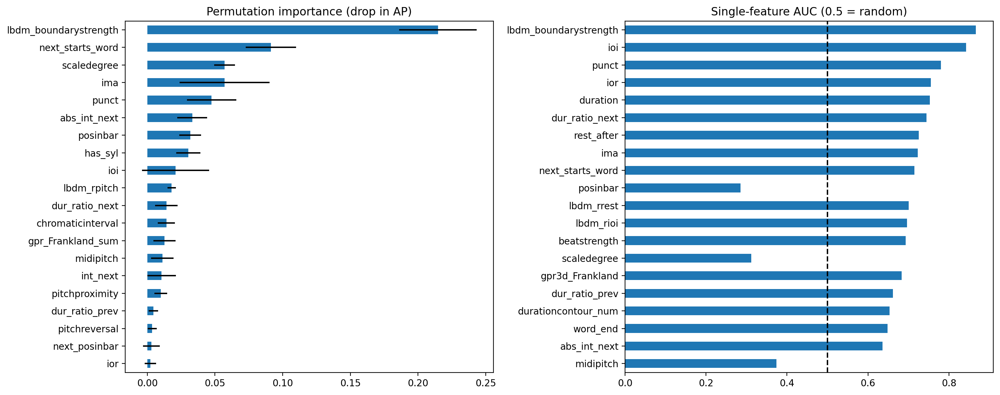

In [ ]:
#@title Q3.1 Permutation importance (multivariate model, CV grouped by song)
gkf = GroupKFold(n_splits=5)
imps, aps = [], []
for k, (tr, te) in enumerate(gkf.split(Xf, yf, groups)):
    clf = HistGradientBoostingClassifier(max_iter=300, learning_rate=0.08, class_weight='balanced', random_state=k)
    clf.fit(Xf.iloc[tr], yf[tr])
    p = clf.predict_proba(Xf.iloc[te])[:, 1]
    aps.append(average_precision_score(yf[te], p))
    # sample of the test fold to keep the permutation fast
    te_s = np.random.default_rng(k).choice(te, size=min(len(te), 20000), replace=False)
    r = permutation_importance(clf, Xf.iloc[te_s], yf[te_s], scoring='average_precision', n_repeats=5, random_state=k, n_jobs=-1)
    imps.append(pd.Series(r.importances_mean, index=FEATURES))
imp = pd.concat(imps, axis=1)
q3 = pd.DataFrame({'mean importance (AP drop)': imp.mean(axis=1), 'std across folds': imp.std(axis=1)}).sort_values('mean importance (AP drop)', ascending=False).round(4)
display(q3); save(q3, 'Q3_permutation_importance')
log('Q3', f'HistGradientBoosting (5-fold CV grouped by song): average precision {np.mean(aps):.3f} ± {np.std(aps):.3f} (base rate {yf.mean():.3f})')
log('Q3', 'Most important features (permutation): ' + ', '.join(f'{i} ({v:.3f})' for i, v in q3.iloc[:8, 0].items()))
log('Q3', 'Most discriminative features alone (AUC): ' + ', '.join(f'{i} ({v:.2f})' for i, v in uni['AUC'].head(8).items()))

fig, ax = plt.subplots(1, 2, figsize=(15, 6))
q3.iloc[:20, 0][::-1].plot.barh(xerr=q3.iloc[:20, 1][::-1], ax=ax[0], title='Permutation importance (drop in AP)')
uni['AUC'].head(20)[::-1].plot.barh(ax=ax[1], title='Single-feature AUC (0.5 = random)'); ax[1].axvline(.5, color='k', ls='--')
plt.tight_layout(); save('fig', 'Q3_importance'); plt.show()

### Q8. Distribution by country and genre
Genres come from `<term type="genre">`. The cleaning follows the one in "Clean Dataset", extended to other values.
The distribution is shown for all files and for the files with annotated phrases only.

,files
genre_raw,
Children song,588
None,487
NaN,381
Childhood Music,335
Lullaby,173
Narrative Genre,169
Community Festive Secular Music,98
canción infantil,84
Religious and Ritual Music,55


All files:


genre,Childhood Music,Community festive secular music,Dance,Filastrocca,Lullaby,Narrative genre,No genre,Religious and ritual music,Work music,Total
country,,,,,,,,,,
CO,92,0,0,0,0,0,0,0,0,92
ES,592,0,1,0,154,0,635,0,0,1382
IE,0,0,0,0,0,0,189,0,0,189
IR,0,0,0,0,0,0,6,0,0,6
IT,47,0,0,1,12,0,0,0,0,60
MI,23,0,0,0,0,0,38,0,0,61
MX,220,98,8,0,0,169,0,55,15,565
PT,52,0,0,0,7,0,0,0,0,59
Total,1026,98,9,1,173,169,868,55,15,2414


Files with annotated phrases (usable for training):


genre,Childhood Music,Dance,Filastrocca,Lullaby,Total
country,,,,,
ES,441,1,0,83,525
IT,36,0,1,10,47
PT,52,0,0,7,59
Total,529,1,1,100,631


All files by country: {'ES': 1382, 'MX': 565, 'IE': 189, 'CO': 92, 'MI': 61, 'IT': 60, 'PT': 59, 'IR': 6}
Annotated by country: {'ES': 525, 'PT': 59, 'IT': 47}
Annotated by genre: {'Childhood Music': 529, 'Lullaby': 100, 'Dance': 1, 'Filastrocca': 1}


songs  notes  phrases  notes/phrase
country genre                                               
ES      Childhood Music    441  31864     1725          18.5
        Dance                1     74        4          18.5
        Lullaby             83   4560      250          18.2
IT      Childhood Music     36   1813       89          20.4
        Filastrocca          1     50        2          25.0
        Lullaby             10    761       28          27.2
PT      Childhood Music     52   6746      499          13.5
        Lullaby              7    459       34          13.5

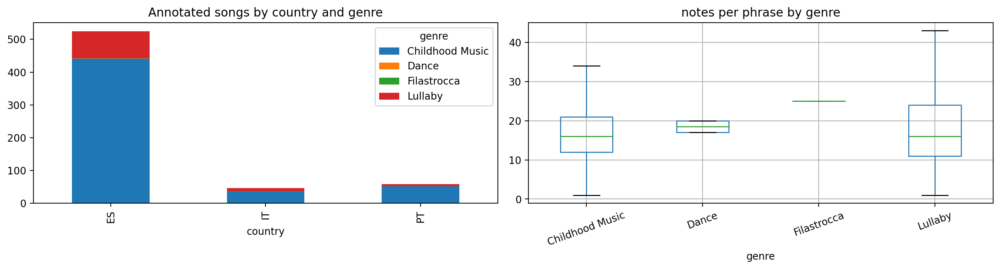

In [ ]:
def clean_genre(g):
    if not isinstance(g, str) or not g.strip():
        return 'No genre'
    s = g.lower()
    if re.search(r'lul|nana|cuna|embalar|arrullo|ninna', s): return 'Lullaby'
    if re.search(r'child|corro|canción|infantil|juego|jogo|roda', s): return 'Childhood Music'
    if re.search(r'narrat|romance|ballad|corrido', s): return 'Narrative genre'
    if re.search(r'dan|baile|jota|dance', s): return 'Dance'
    return g.strip().capitalize()
audit['genre'] = audit['genre_raw'].map(clean_genre)
songs['genre'] = audit.set_index('song_id').loc[songs.index, 'genre']

q8_raw = audit['genre_raw'].value_counts(dropna=False).rename('files')
display(q8_raw.head(30)); save(q8_raw, 'Q8_original_genres')

q8_all = pd.crosstab(audit['country'], audit['genre'], margins=True, margins_name='Total')
q8_ann = pd.crosstab(songs['country'], songs['genre'], margins=True, margins_name='Total')
print('All files:'); display(q8_all)
print('Files with annotated phrases (usable for training):'); display(q8_ann)
save(q8_all, 'Q8_country_genre_all'); save(q8_ann, 'Q8_country_genre_annotated')
log('Q8', f"All files by country: {as_dict(audit['country'].value_counts())}")
log('Q8', f"Annotated by country: {as_dict(songs['country'].value_counts())}")
log('Q8', f"Annotated by genre: {as_dict(songs['genre'].value_counts())}")

strata = songs.groupby(['country', 'genre']).agg(songs=('n_notes_unfolded', 'size'), notes=('n_notes_unfolded', 'sum'),
                                                 phrases=('n_phrases_unfolded', 'sum'))
strata['notes/phrase'] = (strata['notes'] / strata['phrases']).round(1)
display(strata); save(strata, 'Q8_strata')

fig, ax = plt.subplots(1, 2, figsize=(14, 4))
q8_ann.drop(index='Total', columns='Total').plot.bar(stacked=True, ax=ax[0], title='Annotated songs by country and genre')
ph.join(songs['genre'], on='song_id').boxplot(column='n_notes', by='genre', ax=ax[1], showfliers=False, rot=20)
ax[1].set_title('notes per phrase by genre'); plt.suptitle('')
plt.tight_layout(); save('fig', 'Q8_country_genre'); plt.show()

### Q9. Are there duplicated songs?
Four levels, from strictest to broadest:
1. **Identical file** (same MD5) or **same ID** in different folders (including the legacy folders, as a check);
2. **Identical melody**: same pitch and duration sequence (unfolded), even with different metadata;
3. **Same melody transposed**: same interval and duration sequence;
4. **Variants**: same normalised title (ignoring "(a)", "(b)", numbers) or same melodic opening (24 intervals).

To avoid leakage, songs from the same group should stay in the same fold; `Q9_duplicate_groups.csv` can be used
directly as `groups` in a `GroupKFold`.

In [ ]:
dup_md5 = audit[audit.duplicated('md5', keep=False)].sort_values('md5')
dup_id = audit[audit.duplicated('song_id', keep=False)].sort_values('song_id')
legacy = sorted(f for d in LEGACY_FOLDERS for f in glob.glob(os.path.join(DATA_DIR, d, '**', '*.mei'), recursive=True))
legacy_ids = {song_id_from_path(f) for f in legacy}
log('Q9', f'Legacy folders {LEGACY_FOLDERS}: {len(legacy)} files, {len(legacy_ids & set(audit.song_id))} with the same ID as a '
          f'current file (excluded from the analyses to avoid duplicates)')

def seq_key(d, transposed=False):
    p = d['midipitch'].values; du = d['duration'].values
    p = np.diff(p) if transposed else p
    return hashlib.md5(json.dumps([list(map(float, p)), list(map(float, du))]).encode()).hexdigest()
keys = pd.DataFrame({'exact': notes.groupby('song_id').apply(seq_key),
                     'transposed': notes.groupby('song_id').apply(lambda d: seq_key(d, True)),
                     'incipit24': notes.groupby('song_id')['midipitch'].apply(lambda s: str(tuple(np.diff(s.values)[:24])) if len(s) > 12 else None)})
songs = songs.join(keys)

def norm_title(t):
    t = re.sub(r'\(\w\)|\d+\.?|[^\w\s]', ' ', str(t).lower())
    return re.sub(r'\s+', ' ', t).strip()
songs['title_norm'] = songs['title'].map(norm_title)
NO_TITLE = {'', 'no title', 'sem titulo', 'sem título', 'sin titulo', 'sin título', 'none', 'nan'}

# Connected components (union-find) for the variant groups
parent = {s: s for s in songs.index}
def find(a):
    while parent[a] != a:
        parent[a] = parent[parent[a]]; a = parent[a]
    return a
def link(col, skip=()):
    for k, grp in songs.groupby(col).groups.items():
        if k in skip or k is None:
            continue
        grp = list(grp)
        for s in grp[1:]:
            parent[find(s)] = find(grp[0])
for col in ['exact', 'transposed', 'incipit24']:
    link(col)
link('title_norm', skip=NO_TITLE)
songs['dup_group'] = [find(s) for s in songs.index]

def n_in_groups(col, skip=()):
    vc = songs[~songs[col].isin(skip)][col].value_counts()
    return int((vc > 1).sum()), int(vc[vc > 1].sum())
vg = songs['dup_group'].value_counts()
q9 = pd.DataFrame({
    'identical file (MD5)': (dup_md5['md5'].nunique(), len(dup_md5)),
    'same ID in different folders': (dup_id['song_id'].nunique(), len(dup_id)),
    'identical melody (pitches + durations)': n_in_groups('exact'),
    'same melody transposed': n_in_groups('transposed'),
    'same melodic opening (24 intervals)': n_in_groups('incipit24'),
    'same normalised title': n_in_groups('title_norm', NO_TITLE),
    'variant groups (any criterion)': (int((vg > 1).sum()), int(vg[vg > 1].sum())),
}, index=['groups', 'songs involved']).T
display(q9); save(q9, 'Q9_duplicates_summary')
for k, r in q9.iterrows():
    log('Q9', f"{k}: {r['groups']} groups, {r['songs involved']} songs")

dup_table = songs[songs.dup_group.isin(vg[vg > 1].index)].sort_values(['dup_group']).reset_index()[
    ['dup_group', 'song_id', 'title', 'country', 'collection', 'genre', 'n_notes_unfolded', 'exact', 'transposed']]
dup_table['same_melody_as_another'] = dup_table.duplicated('exact', keep=False)
display(dup_table.head(30))
save(dup_table, 'Q9_duplicates_detail', index=False)
save(songs[['dup_group', 'country', 'genre', 'collection']], 'Q9_duplicate_groups')
cross = dup_table.groupby('dup_group')['collection'].nunique()
log('Q9', f'Groups spanning different songbooks: {int((cross > 1).sum())}')

Legacy folders ['Spanish', 'Portuguese', 'Mexican']: 1126 files, 363 with the same ID as a current file (excluded from the analyses to avoid duplicates)


,groups,songs involved
identical file (MD5),0,0
same ID in different folders,0,0
identical melody (pitches + durations),4,8
same melody transposed,4,8
same melodic opening (24 intervals),11,22
same normalised title,35,90
variant groups (any criterion),37,98


identical file (MD5): 0 groups, 0 songs
same ID in different folders: 0 groups, 0 songs
identical melody (pitches + durations): 4 groups, 8 songs
same melody transposed: 4 groups, 8 songs
same melodic opening (24 intervals): 11 groups, 22 songs
same normalised title: 35 groups, 90 songs
variant groups (any criterion): 37 groups, 98 songs


,dup_group,song_id,title,country,collection,genre,n_notes_unfolded,exact,transposed,same_melody_as_another
0,ES-1943-SA-ASF-128,ES-1943-SA-ASF-128,De Comba,ES,ES-1943-ASF,Childhood Music,91,42ee38ec1b20505609107392c0cd7275,f00011ecf0fa3dfc61b5675b48114a99,False
1,ES-1943-SA-ASF-128,ES-1948-CB-CO1-256,Pasea Una Dama,ES,ES-1948-CO1,Childhood Music,97,7c04ffd1c46026ef918de6968dc23826,e12ecd44e8e16194147a314b6c295393,False
2,ES-1943-SA-ASF-174,ES-1948-CB-CO1-107,Con El Guri,ES,ES-1948-CO1,Childhood Music,64,ccec9db60d16ecb3cf7c3e5d650499f0,802fcc96972d25985513a1539aea9209,False
3,ES-1943-SA-ASF-174,ES-1948-CB-CO1-124,En El Balcón De Palacio,ES,ES-1948-CO1,Childhood Music,40,898779e25d4bebcfe8e3c19e0f0bd5fc,91e1b2658cc4d423343a1bad9dd6ecc0,False
4,ES-1943-SA-ASF-174,ES-1943-SA-ASF-174,En El Balcón De Palacio,ES,ES-1943-ASF,Childhood Music,32,7a6c34b68b80345c097ddd3601817cbf,d3a30a068b52439aaa80db9302fce6ee,False
5,ES-1943-SA-ASF-184,ES-1948-CB-CO1-096,96. Al buen Jesús; 96. Al buen Jesús,ES,ES-1948-CO1,Childhood Music,72,9219954a6cafde1247e104fee7399b0c,093610276b781805c4c583840bf44a3d,False
6,ES-1943-SA-ASF-184,ES-1943-SA-ASF-184,Al Buen Jesús,ES,ES-1943-ASF,Childhood Music,36,9151bfe415e6da6323ea7bc20881ddc8,e4b496607dddbac8d1a3ee8b9db40ac9,False
7,ES-1943-SA-ASF-213,ES-1943-SA-ASF-213,Estaba La Pájara Pinta,ES,ES-1943-ASF,Childhood Music,141,88a111c0c456748625dbd2a937e8015a,67b7e04030405f42634fc2ce70f4b028,False
8,ES-1943-SA-ASF-213,ES-1948-CB-CO1-294,Estaba La Pájara Pinta,ES,ES-1948-CO1,Childhood Music,156,bc98548e4599cad1c1f1816e1cdcf8f2,a48ed0773609ffea74b3462ab9a6c6d7,False
9,ES-1943-SA-ASF-244,ES-1943-SA-ASF-244,"Te Tengo Te Tengo, Que Tengo Que Dar",ES,ES-1943-ASF,Childhood Music,44,ca5e4f5def1fed802d88f5ab913e7f6d,6b46ba36bb2501b7f675de4e3025e042,True


Groups spanning different songbooks: 12


### Final record
Writes a summary (`summary.md`) with every line logged above, plus the note and song tables.

In [ ]:
with open(os.path.join(RESULTS_DIR, 'summary.md'), 'w', encoding='utf-8') as fh:
    fh.write(f'# EA-Digifolk - phrase segmentation analyses\n\nGenerated on {datetime.now():%Y-%m-%d %H:%M}\n')
    for q in ['setup', 'Q1', 'Q2', 'Q3', 'Q4', 'Q5', 'Q6', 'Q7', 'Q8', 'Q9']:
        lines = [t for qq, t in LOG if qq == q]
        if lines:
            fh.write(f'\n## {q}\n\n' + '\n'.join(f'- {t}' for t in lines) + '\n')
KEEP = ['song_id', 'pos', 'id', 'midipitch', 'duration', 'timesignature', 'beatstrength', 'posinbar', 'rest_after',
        'scaledegree', 'chromaticinterval', 'ioi', 'ior', 'syl', 'syllabic', 'phrase_ix', 'y', 'y_parser', 'y_ix']
notes[[c for c in KEEP if c in notes]].to_csv(os.path.join(RESULTS_DIR, 'notes.csv.gz'), index=False, compression='gzip')
save(songs.drop(columns=['exact', 'transposed', 'incipit24'], errors='ignore'), 'songs')
print(open(os.path.join(RESULTS_DIR, 'summary.md'), encoding='utf-8').read())
print('Files in', RESULTS_DIR, ':', sorted(os.listdir(RESULTS_DIR)))

# EA-Digifolk - phrase segmentation analyses

Generated on 2026-10-06 13:53

## setup

- Dataset commit ac3f8f8 2026-06-30 22:37:06 +0000 | 2414 MEI files in ['Spain', 'Portugal', 'Mexico', 'Italy', 'Colombia', 'Ireland', 'Miscellanous'] | 2026-10-06 13:52
- Files read: 2414 | XML read errors / files without <body>: 381
- Annotated songs with note features: 638 of 639 (1 missing: parser errors, see PARSE_ERRORS / the "Process Dataset" output)
- Note table: 46327 notes in 631 songs | 7 songs with no locatable phrase skipped | parser without phrase features in 106 songs (labels computed from the MEI)

## Q1

- Files with annotated phrases: 639 of 2414 (26.5%) | total phrases: 2875
- supplied/@type (all): {'phrases': 831, 'rythymn pattern': 789, 'rhythm pattern': 59, 'None': 2}
- supplied/@type with phrases: {'phrases': 637, 'None': 2}
- phrase/@type (top 15): {'A': 1350, 'B': 632, 'A2': 419, 'CODA': 190, 'C': 74, 'B2': 74, 'D': 33, 'A3': 27, 'B1': 14, 'INTRO': 12, 'A1': 11, 'C2': 10, 'A4